In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pysindy as ps
import matplotlib.pyplot as plt
import xarray as xr
import torch
import torch.nn as nn
from tqdm import trange
from torchmetrics.regression import R2Score
from torch.utils.data import Dataset, DataLoader
import os
from pathlib import Path
from datetime import datetime
from data_utils import load_DYAMOND_data, load_grid
from train_ODE_and_parametrization import load_NNODE_checkpoint
from data_utils import CoordDataset
from torch.utils.data import DataLoader
import warnings
import pickle
from parametrizations import BaseParametrization
import sympy as sp
from sympy.parsing.sympy_parser import (
    parse_expr,
    standard_transformations,
    implicit_multiplication_application
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [2]:
# Load Z data
#XZ_train = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260129150710_global_ocean_land_rp=False_Ztrain_ConvNN+AE+D_tp=20_wd=0.0.npy')
#XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260129150710_global_ocean_land_rp=False_Zval_ConvNN+AE+D_tp=20_wd=0.0.npy')
#XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260417112208_global_ocean_land_rp=False_Ztest_ConvNN+AE+D_tp=20_wd=None.npy')
#XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260417112208_global_ocean_land_rp=False_Zval_ConvNN+AE+D_tp=20_wd=None.npy')
XZ_train = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507185408_global_ocean_land_rp=False_Ztrain_ConvNN+AE+D_tp=20_wd=0.0.npy')
XZ_val = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507185408_global_ocean_land_rp=False_Zval_ConvNN+AE+D_tp=20_wd=0.0.npy')
XZ_test = np.load('Z_data/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260507185408_global_ocean_land_rp=False_Ztest_ConvNN+AE+D_tp=20_wd=0.0.npy')

### Train ODE

In [4]:
sep = 10
all_features = np.array(['coord', 'qv2m', 'Prw', 'T2m', 'Ts', 'Fs', 'Fl', 'l', 'z1', 'z2', 'z3', 'z4'])
x_inds = [1, 2, 3, 4, 5, 6]
first_z_ind = -4
feature_names = list(all_features[first_z_ind:]) + list(all_features[x_inds]) 
x_train= list(XZ_train[::sep, :, x_inds])
z_train= list(XZ_train[::sep, :, first_z_ind:])
x_val= list(XZ_val[::sep, :, x_inds])
z_val= list(XZ_val[::sep, :, first_z_ind:])

In [5]:
# Learn ODE without other Z_k variables
opt = ps.STLSQ(threshold=0.0)
lib = ps.PolynomialLibrary(degree=1)
model = ps.SINDy(feature_library=lib, 
                 differentiation_method=ps.FiniteDifference(),
                 #differentiation_method=ps.SmoothedFiniteDifference(smoother_kws={'window_length': 10}), 
                 optimizer=opt)

model.fit(x=z_train, u=x_train, t=1, feature_names=feature_names)
model.print()  
model.score(x=z_val, u=x_val, t=1, multioutput='raw_values')

(z1)' = 0.036 1 + -0.021 z1 + -0.028 z2 + -0.002 z3 + 0.002 z4 + 0.030 qv2m + -0.050 Prw + -0.080 T2m + 0.106 Ts + -0.062 Fs + -0.009 Fl
(z2)' = -0.026 1 + 0.059 z1 + 0.008 z2 + 0.021 z3 + 0.015 z4 + 0.165 qv2m + -0.045 Prw + 0.162 T2m + -0.329 Ts + 0.087 Fs + -0.013 Fl
(z3)' = 0.050 1 + -0.048 z1 + -0.029 z2 + -0.018 z3 + -0.006 z4 + -0.014 qv2m + -0.038 Prw + -0.197 T2m + 0.286 Ts + -0.159 Fs + 0.035 Fl
(z4)' = 0.151 1 + -0.183 z1 + -0.069 z2 + -0.067 z3 + -0.036 z4 + -0.315 qv2m + -0.382 T2m + 0.796 Ts + -0.407 Fs + 0.058 Fl


array([0.78064166, 0.28824473, 0.52307145, 0.40662081])

In [ ]:
def save_sindy_equations(model, file_name):
    # Define symbols
    symbols = sp.symbols('qv2m Prw T2m Ts Fs Fl z1 z2 z3 z4')

    # Map names → symbols
    local_dict = {str(s): s for s in symbols}

    # Enable implicit multiplication
    transformations = standard_transformations + (
        implicit_multiplication_application,
    )

    equations = model.equations(precision=16)

    sympy_equations = [
        parse_expr(eq, local_dict=local_dict,
                transformations=transformations)
        for eq in equations
    ]

    with open(f'SINDy_ODEs/equations/{file_name}.pkl', 'wb') as f:
        pickle.dump(sympy_equations, f)
        
save_sindy_equations(model, 'model_20260507185408_linear_ODE_4d_past_timesteps=20')

In [192]:
np.real(np.linalg.eigvals(model.coefficients()[:, 1: 4 + 1]))  # Compute eigenvalues of coefficient matrix corresponding to z variables

array([-0.06117239, -0.06117239, -0.00370833, -0.00932859])

In [40]:
import pandas as pd

In [41]:
model = load_NNODE_checkpoint('networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260508202548_linear_4d_corrected_00_timesteps.pkl')
sympy_eq = model.ODE.sympy()
Xi = {'LHS': [], 'b': [], 'z1': [], 'z2': [], 'z3': [], 'z4': [], 'qv2m': [], 'Prw': [], 'T2m': [], 'Ts': [], 'Fs': [], 'Fl': []}
for i, target in enumerate(['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot']):
    Xi['LHS'].append(target)
    Xi['b'].append(float(sympy_eq[i].as_coeff_add()[1][0]))
    for sym in list(sympy_eq[i].free_symbols):
        Xi[str(sym)].append(float(sympy_eq[i].coeff(sym)))
Xi = pd.DataFrame(Xi)
numeric_cols = Xi.select_dtypes(include='number').columns
Xi_z = Xi[['z1', 'z2', 'z3', 'z4']].values
half_life = np.log(2) / np.real(np.linalg.eigvals(Xi_z)) * 15 / 60
period = 2 *np.pi / np.imag(np.linalg.eigvals(Xi_z)) * 15 / 60
period[np.isinf(period)] = None
Xi['half-life'] = half_life
Xi['period'] = period
# print(Xi['period'].isna())


# styled = (
#     Xi.style
#     .background_gradient(
#         cmap='coolwarm',
#         axis=None,
#         subset=numeric_cols,
#         vmin=-Xi[numeric_cols].abs().values.max(),
#         vmax=Xi[numeric_cols].abs().values.max()
#     )
#     .set_properties(subset=['LHS'], **{'color': 'black'})
#     .set_properties(subset=numeric_cols, **{'color': 'white'})
# )

# print('Eigenvalues Xi_z=', np.linalg.eigvals(Xi_z))
# styled

/tmp/ipykernel_222831/3290675896.py:13: RuntimeWarning: divide by zero encountered in divide
  period = 2 *np.pi / np.imag(np.linalg.eigvals(Xi_z)) * 15 / 60


In [42]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_coefficient_matrix(Xi, fig=None, ax=None):
    plt.rcParams.update({
        "text.usetex": False,
        "font.family": "serif"
    })
    FS = 16

    # --- Labels ---
    latex_map = {
        'LHS': r'$\dot{z}_l$',
        'b': r'$b$',
        'z1': r'$z_1$',
        'z2': r'$z_2$',
        'z3': r'$z_3$',
        'z4': r'$z_4$',
        'z5': r'$z_5$',
        'z6': r'$z_6$',
        'z7': r'$z_7$',
        'z8': r'$z_8$',
        'qv2m': r'$q_{2m}$',
        'Prw': r'$PW$',
        'T2m': r'$T_{2m}$',
        'Ts': r'$T_{sfc}$',
        'Fs': r'$H$',
        'Fl': r'$LE$',
        'X': r'$X$',
        r'$Re(\lambda_i)$': r'$\mathrm{Re}(\lambda_i)$',
        r'$Im(\lambda_i)$': r'$\mathrm{Im}(\lambda_i)$',
        'half-life': r'$\frac{\ln(2)}{\mathrm{Re}(\lambda_i)}$',
        'period': r'$\frac{2\pi}{\mathrm{Im}(\lambda_i)}$'
    }

    eig_real = 'half-life'
    eig_imag = 'period'

    # --- Detect complex eigenvalue column and split ---
    if eig_real not in Xi.columns and eig_imag not in Xi.columns:
        eig_candidates = [c for c in Xi.columns if 'lambda' in c]
        if len(eig_candidates) == 0:
            raise ValueError("No eigenvalue column found.")
        eig_col = eig_candidates[0]

        Xi = Xi.copy()
        # Xi[eig_real] = np.real(Xi[eig_col])
        # Xi[eig_imag] = np.imag(Xi[eig_col])

    # --- Arrange columns ---
    coef_cols = [c for c in Xi.columns if c not in ['LHS', eig_real, eig_imag]]
    cols = coef_cols + [eig_real, eig_imag]

    Xi_numeric = Xi[cols].copy()
    data = Xi_numeric.values

    eig_start = cols.index(eig_real)
    coef_data = data[:, :eig_start]

    # --- Detect z-column boundary ---
    z_start = None
    z_end = 0
    for i, col in enumerate(cols):
        if col.startswith('z') and len(col) > 1 and col[1:].isdigit():
            if z_start is None:
                z_start = i
            z_end = i + 1
        elif z_start is not None and z_end > 0:
            break  # Stop after consecutive z-columns end

    # --- Symmetric color scaling (ONLY coefficients) ---
    vmax = np.abs(coef_data).max()
    vmin = -vmax

    # --- Figure ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    # --- Heatmap (coefficients only) ---
    im = ax.imshow(coef_data, cmap='coolwarm', vmin=vmin, vmax=vmax)

    ax.set_xlim(-0.5, len(cols) - 0.5)
    ax.set_ylim(len(Xi) - 0.5, -0.5)

    # --- White background for eigenvalue columns ---
    for i in range(data.shape[0]):
        for j in range(eig_start, eig_start + 2):
            ax.add_patch(
                plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                              facecolor='white', edgecolor='none')
            )

    # --- Ticks ---
    ax.set_xticks(np.arange(len(cols)))
    ax.set_yticks(np.arange(len(Xi)))

    ax.set_xticklabels(
        [latex_map.get(c, c) for c in cols],
        rotation=45, ha='right', fontsize=FS + 2
    )
    ax.set_yticklabels(
        [rf'$\dot{{z}}_{i+1}$' for i in range(len(Xi))],
        fontsize=FS + 2
    )

    # --- Annotate all values ---
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]

            if j >= eig_start:
                text = f"{val:.2f}"  # eigenvalues (real/imag separately)
            else:
                text = f"{val:.2f}"

            ax.text(j, i, text,
                    ha="center", va="center",
                    color="black", fontsize=FS)

    # --- Separators around z-coefficients ---
    if z_start is not None and z_end > 0:
        # Left of first z-variable
        x_z_left = z_start - 0.5
        ax.axvline(x_z_left, color='black', linewidth=1.5, linestyle='-')
        
        # Right of last z-variable (only if there are non-z coefficients after)
        if z_end < eig_start:
            x_z_right = z_end - 0.5
            ax.axvline(x_z_right, color='black', linewidth=1.5, linestyle='-')

    # --- Double separator before eigenvalues ---
    x_left = eig_start - 0.5
    ax.axvline(x_left - 0.03, color='black', linewidth=1.5)
    ax.axvline(x_left + 0.03, color='black', linewidth=1.5)

    # --- Right border ---
    x_right = eig_start + 1.5
    ax.axvline(x_right, color='black', linewidth=1.5)

    # --- Colorbar ---
    from mpl_toolkits.axes_grid1 import make_axes_locatable

    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2%", pad=0.15)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(r'Coefficient value', fontsize=FS)
    cbar.ax.tick_params(labelsize=FS)

    ax.set_title("")
    #plt.tight_layout()

    return fig, ax

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

def plot_coefficient_matrix(Xi, fig=None, ax=None):
    plt.rcParams.update({
        "text.usetex": False,
        "font.family": "serif"
    })
    FS = 16

    # --- Labels ---
    latex_map = {
        'LHS': r'$\dot{z}_l$',
        'b': r'$b$',
        'z1': r'$z_1$',
        'z2': r'$z_2$',
        'z3': r'$z_3$',
        'z4': r'$z_4$',
        'z5': r'$z_5$',
        'z6': r'$z_6$',
        'z7': r'$z_7$',
        'z8': r'$z_8$',
        'qv2m': r'$q_{2m}$',
        'Prw': r'$PW$',
        'T2m': r'$T_{2m}$',
        'Ts': r'$T_{sfc}$',
        'Fs': r'$H$',
        'Fl': r'$LE$',
        'X': r'$X$',
        r'$Re(\lambda_i)$': r'$\mathrm{Re}(\lambda_i)$',
        r'$Im(\lambda_i)$': r'$\mathrm{Im}(\lambda_i)$',
        'half-life': r'$\frac{\ln(2)}{\mathrm{Re}(\lambda_i)}$',
        'period': r'$\frac{2\pi}{\mathrm{Im}(\lambda_i)}$'
    }

    eig_real = 'half-life'
    eig_imag = 'period'

    # --- Detect complex eigenvalue column and split ---
    if eig_real not in Xi.columns and eig_imag not in Xi.columns:
        eig_candidates = [c for c in Xi.columns if 'lambda' in c]
        if len(eig_candidates) == 0:
            raise ValueError("No eigenvalue column found.")
        eig_col = eig_candidates[0]

        Xi = Xi.copy()
        # Extract real and imaginary parts
        Xi[eig_real] = np.real(Xi[eig_col])
        Xi[eig_imag] = np.imag(Xi[eig_col])

    # --- Arrange columns ---
    coef_cols = [c for c in Xi.columns if c not in ['LHS', eig_real, eig_imag]]
    cols = coef_cols + [eig_real, eig_imag]

    Xi_numeric = Xi[cols].copy()
    data = Xi_numeric.values

    eig_start = cols.index(eig_real)
    coef_data = data[:, :eig_start]

    # --- Detect z-column boundary ---
    z_start = None
    z_end = 0
    for i, col in enumerate(cols):
        if col.startswith('z') and len(col) > 1 and col[1:].isdigit():
            if z_start is None:
                z_start = i
            z_end = i + 1
        elif z_start is not None and z_end > 0:
            break  # Stop after consecutive z-columns end

    # --- Symmetric color scaling (ONLY coefficients) ---
    vmax = np.abs(coef_data).max()
    vmin = -vmax

    # --- Figure ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 4))

    # --- Heatmap (coefficients only) ---
    im = ax.imshow(coef_data, cmap='coolwarm', vmin=vmin, vmax=vmax)

    ax.set_xlim(-0.5, len(cols) - 0.5)
    ax.set_ylim(len(Xi) - 0.5, -0.5)

    # --- White background for eigenvalue columns ---
    for i in range(data.shape[0]):
        for j in range(eig_start, eig_start + 2):
            ax.add_patch(
                plt.Rectangle((j - 0.5, i - 0.5), 1, 1,
                              facecolor='white', edgecolor='none')
            )

    # --- Ticks ---
    ax.set_xticks(np.arange(len(cols)))
    ax.set_yticks(np.arange(len(Xi)))

    ax.set_xticklabels(
        [latex_map.get(c, c) for c in cols],
        rotation=45, ha='right', fontsize=FS + 2
    )
    ax.set_yticklabels(
        [rf'$\dot{{z}}_{i+1}$' for i in range(len(Xi))],
        fontsize=FS + 2
    )

    # --- Annotate all values ---
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            val = data[i, j]

            if j >= eig_start:
                if j == eig_start:  # Real part: half-life
                    text = f"{val:.2f}"
                else:  # Imaginary part → period
                    # Check if imaginary part is effectively zero (real eigenvalue)
                    if abs(val) < 1e-10 or np.isnan(val) or np.isinf(val):
                        text = "—"#"-"
                    else:
                        period = val
                        text = f"{period:.2f}"
            else:
                # Coefficient values
                text = f"{val:.2f}"

            ax.text(j, i, text,
                    ha="center", va="center",
                    color="black", fontsize=FS)

    # --- Separators around z-coefficients ---
    if z_start is not None and z_end > 0:
        # Left of first z-variable
        x_z_left = z_start - 0.5
        ax.axvline(x_z_left, color='black', linewidth=1.5, linestyle='-')
        
        # Right of last z-variable (only if there are non-z coefficients after)
        if z_end < eig_start:
            x_z_right = z_end - 0.5
            ax.axvline(x_z_right, color='black', linewidth=1.5, linestyle='-')

    # --- Double separator before eigenvalues ---
    x_left = eig_start - 0.5
    ax.axvline(x_left - 0.03, color='black', linewidth=1.5)
    ax.axvline(x_left + 0.03, color='black', linewidth=1.5)

    # --- Right border ---
    x_right = eig_start + 1.5
    ax.axvline(x_right, color='black', linewidth=1.5)

    # --- Colorbar ---
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="2%", pad=0.15)

    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label(r'Coefficient value', fontsize=FS)
    cbar.ax.tick_params(labelsize=FS)

    ax.set_title("")
    # plt.tight_layout()

    return fig, ax

In [46]:
#L96_Xi = np.load('/work/bd1179/b309297/L96/ODEs/m=0.001_tau=0.001/dim=8_decoder=True_deg=1_lambda=0.0_finitedifference.npy')
L96_Xi = np.load('/work/bd1179/b309297/L96/ODEs/m=0.001_tau=0.001/dim=6_decoder=True_deg=1_lambda=0.0_finitedifference.npy')
L96_Xi = pd.DataFrame(L96_Xi, columns=['b', 'z1', 'z2', 'z3', 'z4', 'z5', 'z6', 'X'])
L96_Xi['LHS'] = [f'z{i}_dot' for i in range(1, 7)]
L96_Xi_z = L96_Xi[['z1', 'z2', 'z3', 'z4', 'z5', 'z6']].values
L96_Xi['half-life'] = np.log(2) / np.real(np.linalg.eigvals(L96_Xi_z)) 
period =  2 *np.pi / np.imag(np.linalg.eigvals(L96_Xi_z)) 
period[np.isinf(period)] = None
L96_Xi['period'] = period
print(np.linalg.eigvals(L96_Xi_z))

[-1.22484886+10.71404609j -1.22484886-10.71404609j
 -3.26300128 +7.35089443j -3.26300128 -7.35089443j
 -3.05218478 +2.80968077j -3.05218478 -2.80968077j]


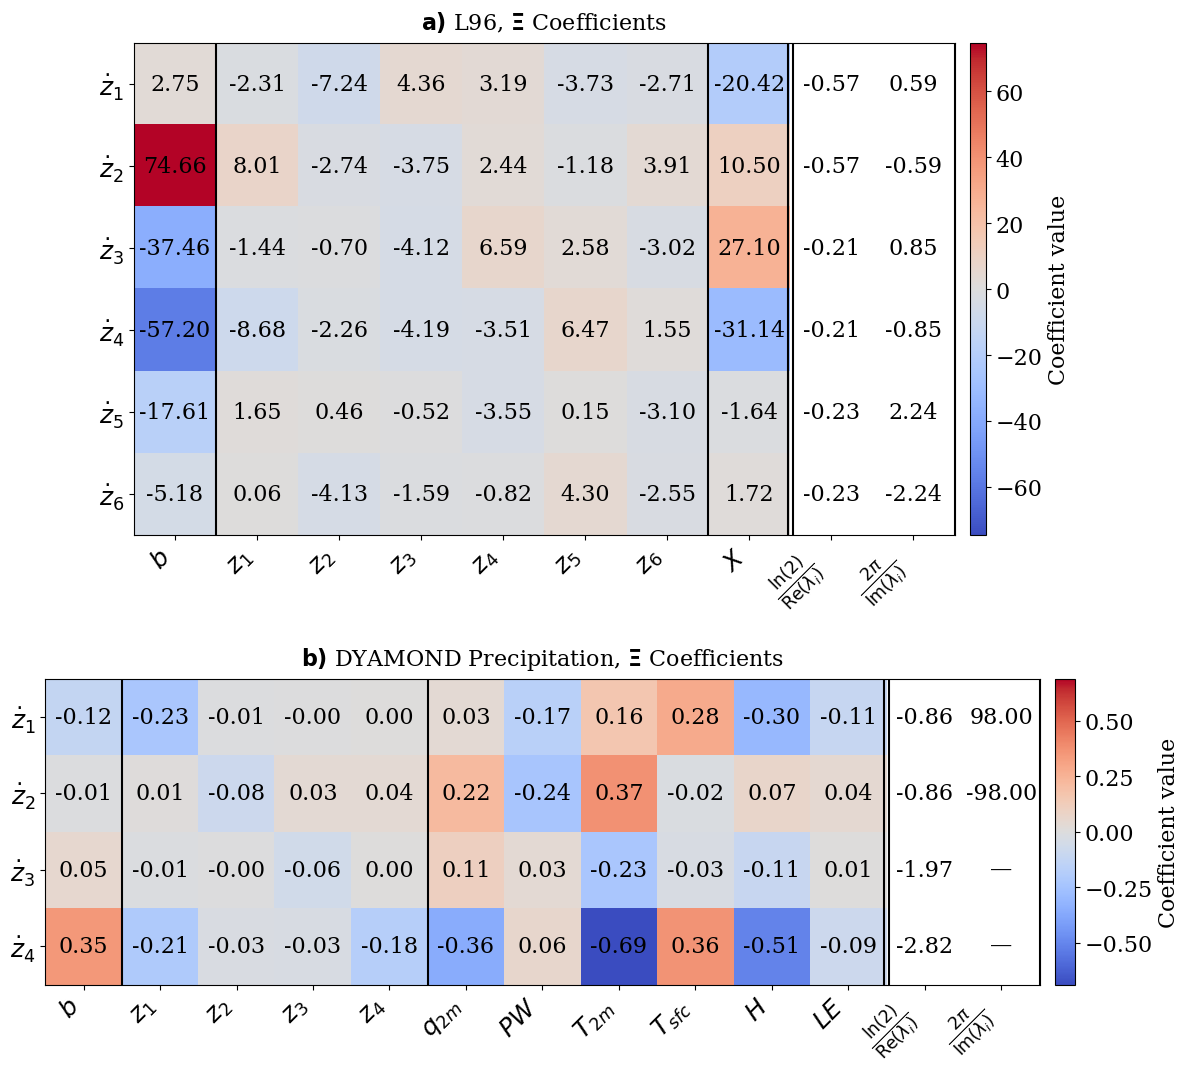

In [55]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- Get actual matrix dimensions ---
n_rows_L96 = L96_Xi.shape[0]  # Number of rows in L96_Xi
n_rows_DYAMOND = Xi.shape[0]   # Number of rows in Xi

# --- Use height ratios based on actual data size ---
height_ratios = [n_rows_L96, n_rows_DYAMOND]

# --- Create figure with constrained layout for minimal whitespace ---
# fig = plt.figure(figsize=(12, 10), constrained_layout=False)  # Let GridSpec handle layout
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(12, 11), gridspec_kw={"height_ratios": [3, 2.5]})

# --- Create subplots (stacked vertically) ---
# ax0 = fig.add_subplot(gs[0, 0])  # Top: L96
# ax1 = fig.add_subplot(gs[1, 0])  # Bottom: DYAMOND

# --- Plot matrices ---
plot_coefficient_matrix(L96_Xi, fig, ax0)
plot_coefficient_matrix(Xi, fig, ax1)

# --- Titles ---
ax0.set_title(r'$\mathbf{a)}$ L96, $\mathbf{\Xi}$ Coefficients', fontsize=16, pad=10)
ax1.set_title(r'$\mathbf{b)}$ DYAMOND Precipitation, $\mathbf{\Xi}$ Coefficients', fontsize=16, pad=10)

# --- Remove extra whitespace and ensure tight layout ---
# Use constrained_layout to avoid padding issues
plt.tight_layout()
plt.savefig('plots_paper/Xi_coefficients_vertical_compact.png', dpi=200, bbox_inches='tight')

sympy.core.add.Add

In [53]:
with open('SINDy_ODEs/equations/model_20260507185408_linear_ODE_4d_past_timesteps=20.pkl', 'rb') as f:
    sympy_eq = pickle.load(f)
Xi_offline = {'LHS': [], 'b': [], 'z1': [], 'z2': [], 'z3': [], 'z4': [], 'qv2m': [], 'Prw': [], 'T2m': [], 'Ts': [], 'Fs': [], 'Fl': []}
for i, target in enumerate(['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot']):
    Xi_offline['LHS'].append(target)
    Xi_offline['b'].append(float(sympy_eq[i].as_coeff_add()[1][0]))
    for sym in list(sympy_eq[i].free_symbols):
        Xi_offline[str(sym)].append(float(sympy_eq[i].coeff(sym)))
Xi_offline = pd.DataFrame(Xi_offline)
numeric_cols = Xi_offline.select_dtypes(include='number').columns
Xi_z = Xi_offline[['z1', 'z2', 'z3', 'z4']].values
half_life = np.log(2) / np.real(np.linalg.eigvals(Xi_z)) * 15 / 60
period = 2 *np.pi / np.imag(np.linalg.eigvals(Xi_z)) * 15 / 60
period[np.isinf(period)] = None
Xi_offline['half-life'] = half_life
Xi_offline['period'] = period

/tmp/ipykernel_222831/3355150576.py:13: RuntimeWarning: divide by zero encountered in divide
  period = 2 *np.pi / np.imag(np.linalg.eigvals(Xi_z)) * 15 / 60


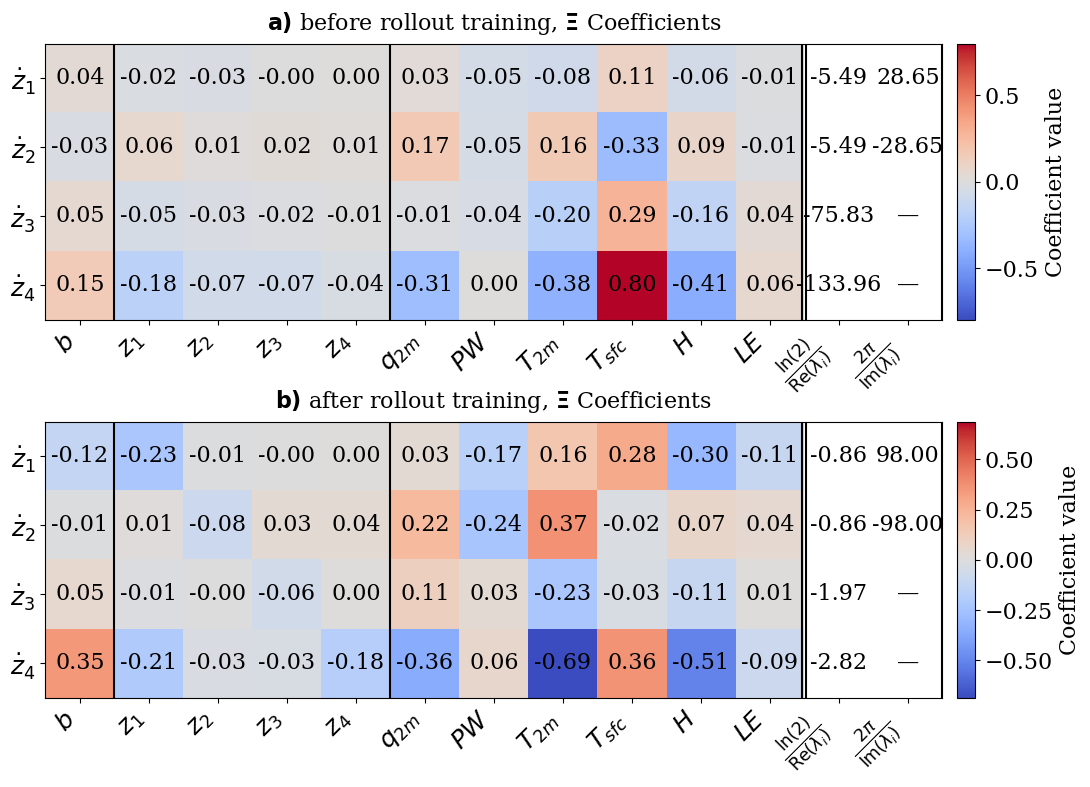

In [54]:
# --- Create figure with constrained layout for minimal whitespace ---
# fig = plt.figure(figsize=(12, 10), constrained_layout=False)  # Let GridSpec handle layout
fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(12, 9))

# --- Create subplots (stacked vertically) ---
# ax0 = fig.add_subplot(gs[0, 0])  # Top: L96
# ax1 = fig.add_subplot(gs[1, 0])  # Bottom: DYAMOND

# --- Plot matrices ---
plot_coefficient_matrix(Xi_offline, fig, ax0)
plot_coefficient_matrix(Xi, fig, ax1)

# --- Titles ---
ax0.set_title(r'$\mathbf{a)}$ before rollout training, $\mathbf{\Xi}$ Coefficients', fontsize=16, pad=10)
ax1.set_title(r'$\mathbf{b)}$ after rollout training, $\mathbf{\Xi}$ Coefficients', fontsize=16, pad=10)

plt.savefig('plots_paper/Xi_coefficients_offline_vs_online.png', dpi=200, bbox_inches='tight')

Text(0, 0.5, 'Memory Kernel Value')

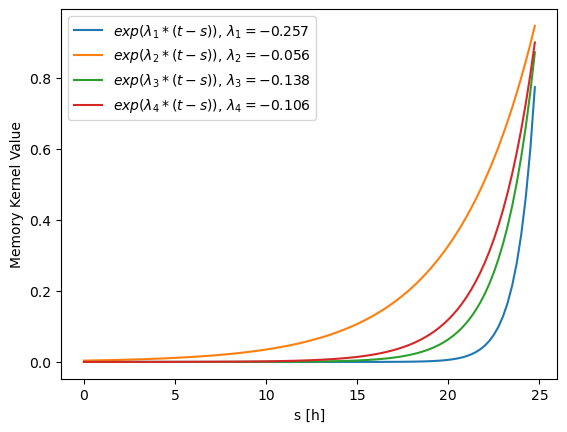

In [49]:
eigenvals = np.real(np.linalg.eigvals(Xi_z))
t = 100
s = np.arange(0, t)
for i in range(4):
    plt.plot(s*15/60, np.exp(eigenvals[i] * (t-s)), label=rf'$exp(\lambda_{{{1+i}}} * (t-s)),\, \lambda_{{{i+1}}}= {eigenvals[i]:.3f}$')
plt.legend()
plt.xlabel('s [h]')
plt.ylabel('Memory Kernel Value')

In [20]:
with open('linear_ODE_4d_sympy_equations.pkl', 'rb') as f:
    model_offline = pickle.load(f)

In [ ]:
sympy_eq = model_offline

Xi = {'LHS': [], 'b': [], 'z1': [], 'z2': [], 'z3': [], 'z4': [], 'qv2m': [], 'Prw': [], 'T2m': [], 'Ts': [], 'Fs': [], 'Fl': []}
for i, target in enumerate(['z1_dot', 'z2_dot', 'z3_dot', 'z4_dot']):
    Xi['LHS'].append(target)
    Xi['b'].append(float(sympy_eq[i].as_coeff_add()[1][0]))
    for sym in list(sympy_eq[i].free_symbols):
        Xi[str(sym)].append(float(sympy_eq[i].coeff(sym)))
Xi = pd.DataFrame(Xi)

numeric_cols = Xi.select_dtypes(include='number').columns
styled = (
    Xi.style
    .background_gradient(
        cmap='coolwarm',
        axis=None,
        subset=numeric_cols,
        vmin=-Xi[numeric_cols].abs().values.max(),
        vmax=Xi[numeric_cols].abs().values.max()
    )
    .set_properties(subset=['LHS'], **{'color': 'black'})
    .set_properties(subset=numeric_cols, **{'color': 'white'})
)
Xi_z = Xi[['z1', 'z2', 'z3', 'z4']].values
print('Re(Eigenvalues Xi_z)=', np.real(np.linalg.eigvals(Xi_z)))
styled

[[-0.02971172 -0.02425717  0.01301814  0.01616567]
 [ 0.09779976 -0.05195794 -0.09447321 -0.04361043]
 [ 0.03666716  0.01449423 -0.03763004 -0.01960495]
 [ 0.00959557  0.06438061  0.00821035 -0.016082  ]]
Re(Eigenvalues Xi_z)= [-0.06117239 -0.06117239 -0.00370833 -0.00932859]


,LHS,b,z1,z2,z3,z4,qv2m,Prw,T2m,Ts,Fs,Fl
0,z1_dot,0.012919,-0.029712,-0.024257,0.013018,0.016166,-0.072469,0.033567,-0.006730,0.034683,-0.228323,0.012585
1,z2_dot,-0.353117,0.097800,-0.051958,-0.094473,-0.043610,-0.118159,0.376612,-0.204319,-0.166991,0.809024,-0.122431
2,z3_dot,-0.128743,0.036667,0.014494,-0.037630,-0.019605,-0.017634,0.064907,0.074963,-0.031355,0.285316,0.007387
3,z4_dot,0.020303,0.009596,0.064381,0.008210,-0.016082,-0.032744,-0.140761,0.208539,0.096897,0.392152,-0.127668


In [22]:
sympy_eq[1]

-0.1224308237433434*Fl + 0.8090240955352783*Fs + 0.3766121864318848*Prw - 0.2043185532093048*T2m - 0.1669906079769135*Ts - 0.1181593537330627*qv2m + 0.0977997630834579*z1 - 0.051957942545414*z2 - 0.0944732129573822*z3 - 0.0436104275286198*z4 - 0.3531173169612885

In [193]:
coord = 1234
tmax = x_train[coord].shape[0]
z_sim = model.simulate(z_train[coord][0], u=x_train[coord][:tmax], t=np.arange(tmax))

/work/bd1179/b309297/conda_envs/DYAMOND_env/lib/python3.13/site-packages/pysindy/pysindy.py:748: UserWarning: Last time point dropped in simulation because interpolation of control input was used. To avoid this, pass in a callable for u.
  warnings.warn(


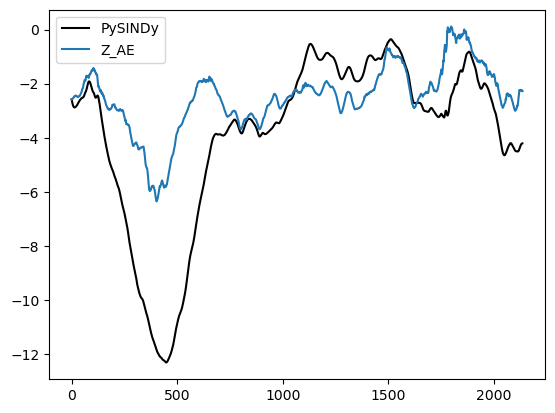

In [194]:
var = 2
plt.plot(z_sim[:tmax, var], label='PySINDy', color='black')
plt.plot(z_train[coord][:tmax, var], label='Z_AE')
plt.legend()

In [195]:
import sympy as sp
import pickle
from sympy.parsing.sympy_parser import (
    parse_expr,
    standard_transformations,
    implicit_multiplication_application
)

# Define symbols
symbols = sp.symbols('qv2m Prw T2m Ts Fs Fl z1 z2 z3 z4')

# Map names → symbols
local_dict = {str(s): s for s in symbols}

# Enable implicit multiplication
transformations = standard_transformations + (
    implicit_multiplication_application,
)

equations = model.equations(precision=16)

sympy_equations = [
    parse_expr(eq, local_dict=local_dict,
               transformations=transformations)
    for eq in equations
]

# with open('linear_ODE_4d_sympy_equations.pkl', 'wb') as f:
#     pickle.dump(sympy_equations, f)

In [ ]:
import sympytorch
from data_utils import CoordDataset
from torch.utils.data import DataLoader
import warnings
import pickle
from parametrizations import BaseParametrization
models_st = sympytorch.SymPyModule(expressions=sympy_equations)

In [197]:
inputs = [str(fn) for fn in model.feature_names]
inputs #+= ['Precip']
inputs

['z1', 'z2', 'z3', 'z4', 'qv2m', 'Prw', 'T2m', 'Ts', 'Fs', 'Fl']

In [ ]:
coords = [123, 255]
# coords = np.arange(8192)
X = torch.tensor(np.array(x_train))[coords]
Z = torch.tensor(np.array(z_train))[coords]
print(X.shape)
tmax = 1000  #X.shape[1]
latent_dims=4
Z_ED = torch.zeros(size=(tmax, len(coords), latent_dims))
dt = 1

Z_sim = []#[Z[:, 0, :].detach().numpy()]
z = Z[:, 0, :]
for t in range(0, tmax):
    xz = torch.cat((z, X[:,t]), dim=1).T
    symbols = dict(zip(inputs, xz))
    z = z + models_st.forward(**symbols) * dt  # Euler Step
    Z_ED[t] = z

torch.Size([2, 2137, 6])


In [149]:
coords = [1234, 255, 355]
X = torch.tensor(np.array(x_train))[coords]
Z = torch.tensor(np.array(z_train))[coords]

t_rollout = 1000  
t_prediction = 1000
latent_dims=4
Z_ED_single_t = torch.zeros(size=(t_rollout, len(coords), latent_dims))  # Z_ED saves Z variables at t0 + 1 up to t_prediction
dt = 1

t0 = t_prediction - t_rollout
z = Z[:, t0, :]
for delta_t in range(t_rollout): 
    xz = torch.cat((z, X[:,t0 + delta_t]), dim=1).T
    symbols = dict(zip(inputs, xz))
    z = z + models_st.forward(**symbols) * dt  # Euler Step
    Z_ED_single_t[delta_t] = z

In [198]:
# Allow model to predict from multiple time points
# Treat every prediction point as new coordinate and append to the batch dimension
coords = [1234, 255, 355, 444]
# coords = np.arange(8000)
X = torch.tensor(np.array(x_train))[coords]
Z = torch.tensor(np.array(z_train))[coords]

In [218]:
# # Allow model to predict from multiple time points
# # Treat every prediction point as new coordinate and append to the batch dimension
# coords = [123, 255, 355, 444]
# X = torch.tensor(np.array(x_train))[coords]
# Z = torch.tensor(np.array(z_train))[coords]

t_rollout = 500
tmax = X.shape[1]
t_prediction = np.arange(start=t_rollout, stop=tmax, step=t_rollout)
latent_dims=4
n_forcings=6   # +1 to keep precip
Z_ED = torch.zeros(size=(t_rollout, len(coords) * len(t_prediction), latent_dims))  # Z_ED saves Z variables at t0 + 1 up to t_prediction
XP_batch = torch.zeros(size=(t_rollout, len(coords) * len(t_prediction), n_forcings))
dt = 1

t0 = t_prediction - t_rollout
z = Z[:, t0, :].reshape(-1, latent_dims)  # dim = (coords, prediction_points, laten_dims)
for delta_t in range(t_rollout): 
    x = X[:,t0 + delta_t].reshape(-1, n_forcings)
    zx = torch.cat((z, x), dim=-1)
    symbols = dict(zip(inputs, zx.T))  # Note that we pass precip here, but a proper sympy equation never uses the precip symbol
    z = z + models_st.forward(**symbols) * dt  # Euler Step
    Z_ED[delta_t] = z
    XP_batch[delta_t] = zx[..., latent_dims:]
    
Z_ED_batch = Z_ED.reshape(-1, latent_dims)
XP_batch = XP_batch.reshape(-1, n_forcings)  # Last forcing dim carries precip

Text(0, 0.5, 'Z')

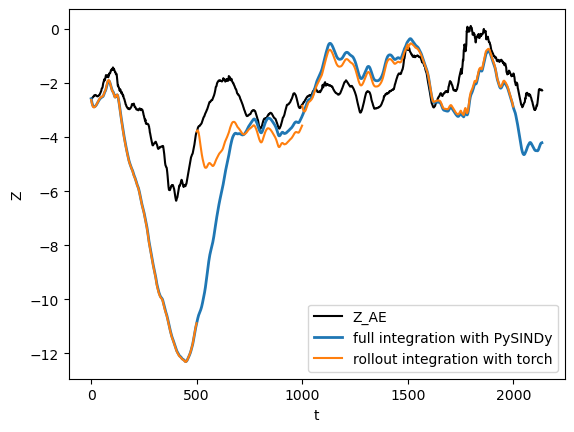

In [220]:
z_ed = Z_ED.reshape(t_rollout, len(coords), len(t_prediction), latent_dims).cpu().detach().numpy()
z_ed.shape
var = 2
plt.plot(Z[0, :tmax , var], color='black', label='Z_AE')
plt.plot(z_sim[:tmax, var], color='tab:blue', label='full integration with PySINDy', linewidth=2)
first = True
for i, tp in enumerate(t_prediction):
    if first:
        first = False
        label = 'rollout integration with torch'
    else:
        label = None
    plt.plot(np.arange(tp-t_rollout, tp), z_ed[:, 0, i, var], color='tab:orange', label=label)
    pass
# plt.plot(Z_ED_single_t.cpu().detach().numpy()[:, 0, var])
plt.legend()
plt.xlabel('t')
plt.ylabel('Z')

In [ ]:
from parametrizations import BaseParametrization

class NN_ODE(nn.Module, BaseParametrization):
    def __init__(self, path_ODE, dt, path_to_AE_model, neural_net=None):
        model_AE = torch.load(path_to_AE_model, map_location=device, weights_only=False)
        past_timesteps, latent_dims =  model_AE.past_timesteps, model_AE.latent_dims
        memory_indices = model_AE.memory_indices
        n_features = model_AE.n_features #len(memory_indices)
        nodes_per_layer = model_AE.nodes_per_layer
        nn.Module.__init__(self)
        BaseParametrization.__init__(self, n_features, past_timesteps, latent_dims, memory_indices,)
        
        self.nodes_per_layer = nodes_per_layer
        self.model_name = 'NN_ODE'
        self.path_ODE = path_ODE
        with open(path_ODE, 'rb') as file:
            self.ODE = pickle.load(file)
        self.dt = dt
        self.inputs = ['qv2m', 'Prw', 'T2m', 'Ts', 'Fs', 'Fl', 'is_land', 'Precip'] + [f'z{i+1}' for i in range(latent_dims)]
        self.n_forcings = self.n_features + 1  # +1 to keep precip

        if not neural_net:  # No NN was passed so we use the NN from the NN+AE model
            self.neural_net = model_AE.neural_net
        else:
            self.neural_net = neural_net
            raise Warning('Custom NN was passed as parametrization. If nodes_per_layer was changed you need to set this attribute manauly. Otherwise nodes_per_layer from the AE is used.')

        # Evaluation
        self.loss = []
        self.train_R2 = []
        self.test_R2 = []
        self.N_diverged_coords = []

    def forward(self, coords, XP, Z, t_prediction, t_rollout):
        Z_ED = torch.zeros(size=(t_rollout, len(coords) * len(t_prediction), self.latent_dims), device=device)  # Z_ED saves Z variables at t0 + 1 up to t_prediction
        XP_batch = torch.zeros(size=(t_rollout, len(coords) * len(t_prediction), self.n_forcings), device=device)
        t0 = t_prediction - t_rollout
        z = Z[:, t0, :].reshape(-1, self.latent_dims)  # dims = (coords, prediction_points, laten_dims)
        for delta_t in range(t_rollout): 
            x = XP[:,t0 + delta_t].reshape(-1, self.n_forcings)
            zx = torch.cat((z, x), dim=-1)
            symbols = dict(zip(self.inputs, zx.T))  # Note that we pass precip here, but sympy equations never use the precip symbol
            z = z + self.ODE.forward(**symbols) * self.dt  # Euler Step
            Z_ED[delta_t] = z
            XP_batch[delta_t] = zx[..., self.latent_dims:]
            
        Z_ED_batch = Z_ED.reshape(-1, self.latent_dims)
        XP_batch = XP_batch.reshape(-1, self.n_forcings)  # Last forcing dim carries precip
        P_batch = XP_batch[:, -1].reshape(-1, 1)
        P_pred_batch = self.neural_net(torch.cat((XP_batch[:, :-1], Z_ED_batch), dim=1))  # Predict precip from input except precip
        return P_batch, P_pred_batch  # Return precip and predicted precip to compute parametrization loss

# model_online = NN_ODE(models_st, dt=1, n_features=6, past_timesteps=20, 
#                latent_dims=latent_dims, memory_indices=[0, 1, 2, 3, 4, 5])
path_NNpAE = 'networks/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260128182053_global_ocean_land_rp=False_alpha=0.5_lr=0.001_weigth_decay=0.0_eps=1.0.pkl'
model_online = NN_ODE(models_st, dt=1, path_to_AE_model=path_NNpAE)
model_online.to(device);

In [3]:
# Load baseline run to get the missing forcings
onlyX_train = np.load('Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260507154339_global_ocean_land_rp=False_Ztrain_NNbase_tp=0_wd=0.0.npy')
onlyX_val = np.load('Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260507154339_global_ocean_land_rp=False_Zval_NNbase_tp=0_wd=0.0.npy')
onlyX_test = np.load('Z_data/NNbase/n_features=7_memory_indices=None_latent_dims=0_past_timesteps=0/20260507154339_global_ocean_land_rp=False_Ztest_NNbase_tp=0_wd=0.0.npy')

In [4]:
onlyX_train = onlyX_train[XZ_train[:, 0, 0].astype(int)]
onlyX_val = onlyX_val[XZ_val[:, 0, 0].astype(int)]
onlyX_test = onlyX_test[XZ_val[:, 0, 0].astype(int)]

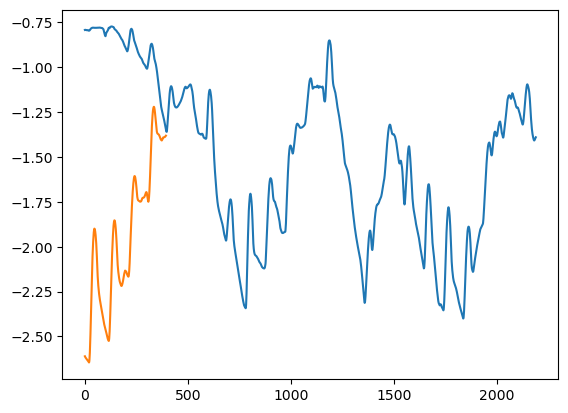

In [5]:
coord, var = 123, 4
plt.plot(onlyX_train[coord, :, var])
plt.plot(onlyX_test[coord, :, var])

In [6]:
onlyX = np.concat((onlyX_train, onlyX_val, onlyX_test), axis=1)
del onlyX_train, onlyX_val, onlyX_test

In [7]:

# Add four empty columns to the last dimension
X_emptyZ_val = np.concatenate((onlyX, np.zeros((onlyX.shape[0], onlyX.shape[1], 4))), axis=-1)
del onlyX

In [8]:
X_emptyZ_val.shape

(81920, 2976, 14)

In [9]:
xp_inds = [1, 2, 3, 4, 5, 6, 7, 8]
latent_dims = 4
# XP_train = torch.tensor(XZ_train[:, :, xp_inds], dtype=torch.float32, device=device)
# XP_val = torch.tensor(XZ_val[:, :, xp_inds], dtype=torch.float32, device=device)
# XP_test = torch.tensor(XZ_test[:, :, xp_inds], dtype=torch.float32, device=device)
# Z_train = torch.tensor(XZ_train[:, :, -latent_dims:], dtype=torch.float32, device=device)
# Z_val = torch.tensor(XZ_val[:, :, -latent_dims:], dtype=torch.float32, device=device)
# Z_test = torch.tensor(XZ_test[:, :, -latent_dims:], dtype=torch.float32, device=device)

# Create merged dataset of val and train, along temporal dimension
XP_emptyZ_val = torch.tensor(X_emptyZ_val[:, :, xp_inds], dtype=torch.float32, device=device)
Z_emptyZ_val = torch.tensor(X_emptyZ_val[:, :, -latent_dims:], dtype=torch.float32, device=device)
# XP_merged = torch.cat((XP_train, XP_emptyZ_val), dim=1)
# Z_merged = torch.cat((Z_train, Z_emptyZ_val), dim=1)
XP_merged = XP_emptyZ_val
Z_merged = Z_emptyZ_val
del XP_emptyZ_val, Z_emptyZ_val, X_emptyZ_val

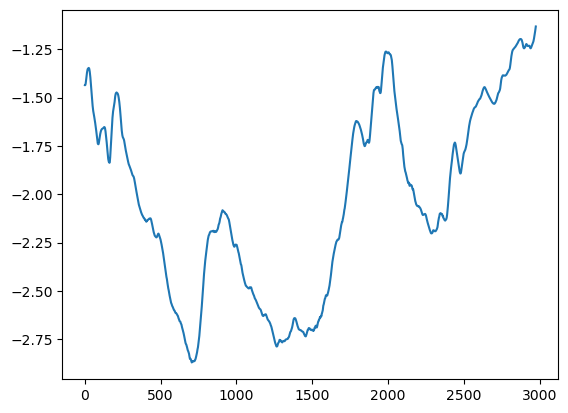

In [10]:
coord, var = 1234, 2
plt.plot(XP_merged[coord, :, var].cpu().detach().numpy(), label='XP merged')

In [39]:
%load_ext autoreload
%autoreload 2
from train_ODE_and_parametrization import NN_ODE
def load_NNODE_checkpoint(path):
    checkpoint = torch.load(path, weights_only=False, map_location=device)
    model = NN_ODE(**checkpoint['model_kwargs'])
    model.ODE.load_state_dict(checkpoint['ODE_state'], )
    model.neural_net.load_state_dict(checkpoint['NN_state'])
    model.set_metadata(checkpoint['metadata'])

    return model

# path = 'networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260318180651.pkl'
path = 'networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260511173500_nonlinear_4d_corrected_00_timesteps_0.pkl'
#path = 'networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260511163124_nonlinear_4d_corrected_00_timesteps.pkl'
model_nonlin = load_NNODE_checkpoint(path)
path = 'nonlinear_ODE_residual_approach_4d_sympy_equations.pkl'
model_residual_nonlin = load_NNODE_checkpoint(path)

# path = 'networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260407224011_nonlinear_residual.pkl'
# model_resnonlin = load_NNODE_checkpoint(path)
path = 'networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260508202548_linear_4d_corrected_00_timesteps.pkl'
model_lin = load_NNODE_checkpoint(path)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


RuntimeError: Invalid magic number; corrupt file?

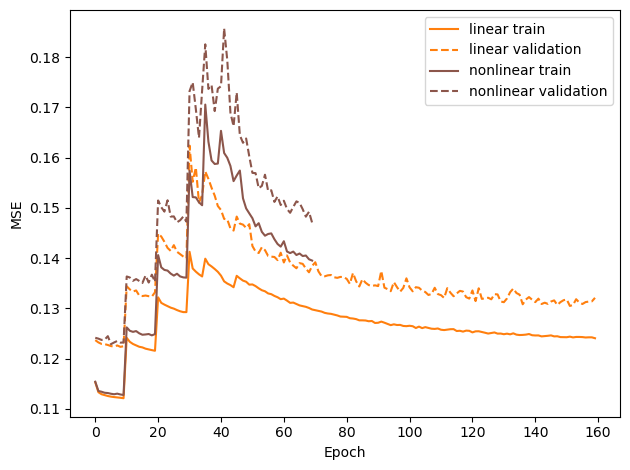

In [4]:
vlines = [0, 100, 200, 210, 220, 230, 235]
t_rollouts = [5, 10, 20, 50, 100, 200, 300]

plt.plot(model_lin.train_loss, label='linear train', color='tab:orange')
plt.plot(model_lin.val_loss, label='linear validation', color='tab:orange', linestyle='--')

# plt.plot(model_resnonlin.train_loss, label='residual nonlinear train', color='tab:orange')
# plt.plot(model_resnonlin.val_loss, label='residual nonlinear validation', color='tab:orange', linestyle='--')

plt.plot(model_nonlin.train_loss, label='nonlinear train', color='tab:brown')
plt.plot(model_nonlin.val_loss, label='nonlinear validation', color='tab:brown', linestyle='--')

#plt.vlines(vlines, ymin=.116, ymax=.15, linestyles='--', color='grey')

# Add text labels
for x, t in zip(vlines, t_rollouts):
    #plt.text(x, 0.115, rf'$t_r={{{t}}}$', ha='center', va='top', fontsize=10, rotation=45)
    pass

plt.xlabel('Epoch')
plt.ylabel('MSE')
# plt.ylim(.11, .15)
plt.legend()
plt.tight_layout()
# plt.savefig('plots_paper/NN_ODE_loss_curves.png', dpi=200, bbox_inches='tight')

In [24]:
with open('qlattice_equations/laten_dims=4_complexity=10_n_epochs=1000/nonlinear_models_selection_sympy.pkl', 'rb') as f:
    sympy_eq_nonlin = pickle.load(f)

In [ ]:
model_nonlin.ODE.sympy() # after rollout training
sympy_eq_nonlin # before rollout training

sympy.core.add.Add

In [38]:
import sympy as sp
from sympy import latex, N, symbols

def create_aligned_latex_with_mapping(equations, var_mapping, sig_figs=3):
    """Create aligned LaTeX equations with variable name mapping"""
    latex_lines = []
    
    # Create symbol mappings
    symbol_map = {}
    for old_name, new_name in var_mapping.items():
        symbol_map[symbols(old_name)] = symbols(new_name)
    
    # Format as aligned equations
    latex_lines.append("\\begin{align*}")
    for i, eq in enumerate(equations):
        # Round constants
        rounded_eq = eq.xreplace({
            c: N(c, sig_figs) for c in eq.atoms() if c.is_number
        })
        
        # Apply variable name mapping
        for old_sym, new_sym in symbol_map.items():
            rounded_eq = rounded_eq.subs(old_sym, new_sym)
        
        latex_str = latex(rounded_eq)
        # Remove "Eq(" and ")" from the beginning/end if present
        if latex_str.startswith("Eq(") and latex_str.endswith(")"):
            latex_str = latex_str[3:-1]
        latex_lines.append(f"\\dot z_{{{i+1}}} &= {latex_str} \\\\")
    latex_lines.append("\\end{align*}")
    
    return "\n".join(latex_lines)

# Variable mapping dictionary
var_mapping = {
    'Prw': 'PW', 
    'T2m': 'T_{\\text{2m}}', 
    'Ts': 'T_{sfc}', 
    'qv2m': 'q_{\\text{2m}}', 
    'Fs': 'H', 
    'Fl': 'LE'
}

# Usage for your equations:
print("Before rollout training:")
print(create_aligned_latex_with_mapping(sympy_eq_nonlin, var_mapping, sig_figs=3))

print("\nAfter rollout training:")
print(create_aligned_latex_with_mapping(model_nonlin.ODE.sympy(), var_mapping, sig_figs=3))

Before rollout training:
\begin{align*}
\dot z_{1} &= - 0.111 H - 0.0205 z_{1} - 0.321 \tanh{\left(0.58 PW + \left(0.694 - 0.127 z_{2}\right) \left(- 1.13 q_{\text{2m}} - 2.6\right) - 0.267 \right)} - 0.285 \\
\dot z_{2} &= - 4.15 \left(- 0.0184 z_{4} - 1.0 \tanh{\left(0.13 z_{1} + 0.0876 z_{2} + 0.906 \right)} + 1.01\right) e^{- 2.0 \left(1.04 - 0.0433 z_{3}\right)^{2.0} - 2.0 \left(- 0.144 H - 0.304\right)^{2.0}} + 0.0608 \\
\dot z_{3} &= 11.8 \left(- 0.000967 z_{4} + e^{- 2.0 \left(0.0544 H + 0.854\right)^{2.0} \left(- 0.00567 z_{2} - 0.648\right)^{2.0} - 2.0 \left(0.0112 z_{1} + 0.542\right)^{2.0}} - 0.314\right) e^{- 2.0 \left(0.0372 z_{3} - 0.706\right)^{2.0}} + 0.0809 \\
\dot z_{4} &= - 20.8 \left(0.384 H - 1.15\right) \left(0.00247 z_{4} + e^{- 2.0 \left(0.0182 z_{1} + 0.943\right)^{2.0} - 2.0 \left(- 0.013 z_{3} - 0.215\right)^{2.0}} - 0.0726\right) - 20.8 \left(- 0.00683 z_{4} - 0.374\right)^{2.0} + 1.06 \\
\end{align*}

After rollout training:
\begin{align*}
\dot z_{1} &= - 

In [13]:
print(XP_merged.shape)
print(Z_merged.shape)

torch.Size([81920, 2976, 8])
torch.Size([81920, 2976, 4])


In [14]:
t_rollout = 2975
# tmax_train = XP_train.shape[1]
# tmax_val = XP_val.shape[1]
# tmax_test = XP_test.shape[1]
tmax_merged = XP_merged.shape[1]
# t_prediction_train = np.arange(start=t_rollout, stop=tmax_train, step=t_rollout)
# t_prediction_val = np.arange(start=t_rollout, stop=tmax_val, step=t_rollout)
# t_prediction_test = np.arange(start=t_rollout, stop=tmax_test, step=t_rollout)
t_prediction_merged = np.arange(start=t_rollout, stop=tmax_merged, step=t_rollout)
coords = np.arange(XP_merged.shape[0], step=1)
#coords = np.array([123])
# XP_batch = XP_train[coords] # grab batch
# Z_batch = Z_train[coords]
# Z_batch = torch.zeros_like(Z_batch)  
# XP_batch = XP_merged[coords] # grab batch
# Z_batch = Z_merged[coords]


In [15]:
Ncoords = XP_merged.shape[0]
Ncoords // 5

16384

In [16]:
t_rollout

2975

In [17]:
Pr_lins = []
Pr_pred_lins = []
Nbatches = 5
for i in range(1, Nbatches + 1):
    print(f'Batch {i}')
    coords_subset = coords[(i-1) * Ncoords//Nbatches: i*Ncoords//Nbatches]
    XP_batch = XP_merged[coords_subset] # grab batch
    Z_batch = Z_merged[coords_subset]
    Pr_lin, Pr_pred_lin = model_lin.forward(coords_subset, XP_batch, Z_batch, t_prediction_merged, t_rollout)
    Pr_lins.append(Pr_lin.cpu().detach().numpy().reshape(t_rollout, -1).T)  # Reshape back to (N_coords, N_timesteps)
    Pr_pred_lins.append(Pr_pred_lin.cpu().detach().numpy().reshape(t_rollout, -1).T)  # Reshape back to (N_coords, N_timesteps)

Batch 1
Batch 2
Batch 3
Batch 4
Batch 5


In [18]:
Pr_lins = np.concatenate(Pr_lins, axis=0)
Pr_pred_lins = np.concatenate(Pr_pred_lins, axis=0)

In [19]:
Pr_lins.shape

(81920, 2975)

In [10]:
Pr_nonlin, Pr_pred_nonlin = model_nonlin.forward(coords, XP_batch, Z_batch, t_prediction_val, t_rollout)

In [11]:
Pr_resnonlin, Pr_pred_resnonlin = model_resnonlin.forward(coords, XP_batch, Z_batch, t_prediction_val, t_rollout)

In [20]:
t_spinup = 30
print('linear model R^2', R2Score()(torch.tensor(Pr_pred_lins[:, t_spinup:]).flatten(), torch.tensor(Pr_lins[:, t_spinup:]).flatten()).item())
# print('nonlinear model R^2', R2Score()(Pr_pred_nonlin, Pr_nonlin).item())
# print('residual nonlinear model R^2', R2Score()(Pr_pred_resnonlin, Pr_resnonlin).item())

linear model R^2 0.6402418613433838


In [69]:
Pr_pred_lins.shape

(81920, 373)

(0.0, 0.2)

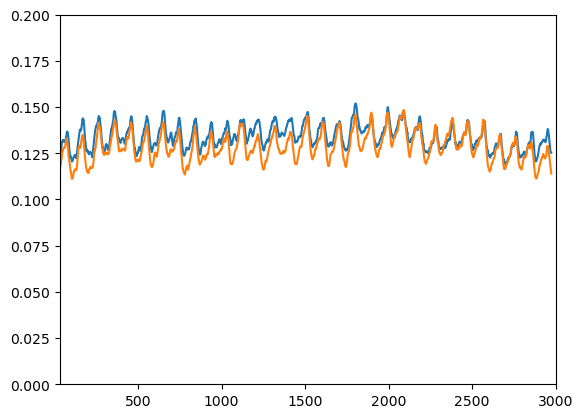

In [24]:
plt.plot(np.mean(Pr_pred_lins, axis=0))
plt.plot(np.mean(Pr_lins, axis=0))
plt.xlim(t_spinup, 3000)
plt.ylim(0, .2)

In [25]:
numpyrize = lambda x: x.cpu().detach().numpy()
Pr_combined = np.array([Pr_pred_lins, Pr_lins])
np.save('precip_ODE_predictions/20260518121043_Pr_combined_merged_linear_ODE_latent_dims=4_tp=20_global_oceanland.npy', Pr_combined)

In [27]:
model_lin.ODE.sympy()

[-0.13960300385952*Fl - 0.463080912828445*Fs + 0.0154420491307974*Prw + 0.180654346942902*T2m + 0.137153655290604*Ts - 0.255898684263229*qv2m - 0.173450037837029*z1 - 0.0344398692250252*z2 + 0.0566940493881702*z3 + 0.0531894378364086*z4 - 0.0916134044528008,
 -0.110719867050648*Fl + 0.315323233604431*Fs + 0.190088391304016*Prw - 0.319011390209198*T2m - 0.246381372213364*Ts + 0.0322087407112122*qv2m + 0.0810164138674736*z1 - 0.0770056322216988*z2 - 0.0230317357927561*z3 - 0.0236820094287395*z4 + 0.00455423444509506,
 0.0671215131878853*Fl + 0.051807589828968*Fs + 0.273259073495865*Prw - 0.191932588815689*T2m - 0.110323578119278*Ts - 0.172032594680786*qv2m + 0.0412504076957703*z1 + 0.0101541299372911*z2 - 0.106519222259521*z3 + 0.0114451823756099*z4 - 0.0781126320362091,
 0.0315445065498352*Fl + 0.789945065975189*Fs - 0.201217830181122*Prw + 0.430773288011551*T2m + 0.201687678694725*Ts + 0.171449899673462*qv2m + 0.155087053775787*z1 + 0.0342328064143658*z2 - 0.0476827621459961*z3 - 0.130

In [29]:
with open(model_lin.path_ODE, 'rb') as file:
    ED_model = pickle.load(file)
    ED_model = SymPyModule(expressions=ED_model)
# for p in ED_model.parameters():
#     print(p)
ED_model.sympy()

[0.0125845298171043*Fl - 0.228322744369507*Fs + 0.0335674025118351*Prw - 0.00673005077987909*T2m + 0.0346834696829319*Ts - 0.0724688395857811*qv2m - 0.0297117158770561*z1 - 0.0242571663111448*z2 + 0.0130181424319744*z3 + 0.0161656737327576*z4 + 0.0129189640283585,
 -0.122430823743343*Fl + 0.809024095535278*Fs + 0.376612186431885*Prw - 0.204318553209305*T2m - 0.166990607976913*Ts - 0.118159353733063*qv2m + 0.0977997630834579*z1 - 0.051957942545414*z2 - 0.0944732129573822*z3 - 0.0436104275286198*z4 - 0.353117316961288,
 0.00738743413239717*Fl + 0.285315543413162*Fs + 0.0649070665240288*Prw + 0.0749631822109222*T2m - 0.0313548110425472*Ts - 0.0176339223980904*qv2m + 0.0366671569645405*z1 + 0.0144942309707403*z2 - 0.0376300364732742*z3 - 0.0196049474179745*z4 - 0.128742828965187,
 -0.12766832113266*Fl + 0.39215213060379*Fs - 0.140761092305183*Prw + 0.208539113402367*T2m + 0.0968972891569138*Ts - 0.0327436849474907*qv2m + 0.00959557015448809*z1 + 0.0643806084990501*z2 + 0.00821035169064999*

In [31]:
# for p in model_nonlin.ODE.parameters():
#     print(p)
model_nonlin.ODE.sympy()

[11.3609142303467*exp(-1.99543464183807*(0.879509687423706*(1.64782214164734 - 0.13083852827549*z1)*exp(-1.99543464183807*(0.00618960056453943*z2 + 0.52697628736496)**2 - 1.99543464183807*(0.00412411941215396*z4 - 0.445239216089249)**2) - 1.02257513999939)**2 - 1.99543464183807*exp(-4.13377618789673*(0.180050507187843 - 0.00277571799233556*z3)**2 - 4.13377618789673*(0.131381765007973*Fs - 0.272840768098831)**2)) - 2.12481546401978,
 4.73603343963623 - 18.9013805389404*exp(-1.99543464183807*(0.027024919167161*z3 + 0.670740306377411)**2 - 1.99543464183807*exp(-4.13377618789673*(1.06048214435577*Fs - 2.8955225944519)**2*exp(-4.13377618789673*(0.0167833343148232*z1 + 1.01049160957336)**2 - 4.13377618789673*(-0.00732459500432014*z4 - 0.520931422710419)**2) - 4.13377618789673*tanh(0.0246263593435287*Fs + 0.590851128101349)**2)),
 -35.1659202575684*exp(-1.99543464183807*(0.0469490811228752*Fs - 0.700505554676056)**2 - 1.99543464183807*(-0.0214981902390718*z4 - 0.217559233307838)**2)*exp(-1.99

In [32]:
with open(model_nonlin.path_ODE, 'rb') as file:
    ED_model = pickle.load(file)
    ED_model = SymPyModule(expressions=ED_model)
# for p in ED_model.parameters():
#     print(p)
ED_model.sympy()

[11.3263368606567*exp(-2.0*(0.916996717453003*(1.69081842899323 - 0.02903569675982*z1)*exp(-2.0*(0.00998869352042675*z2 + 0.496716022491455)**2 - 2.0*(0.00386809254996479*z4 - 0.400003731250763)**2) - 0.996932864189148)**2 - 2.0*exp(-4.0*(0.0257075820118189*Fs - 0.265340983867645)**2 - 4.0*(0.00720689818263054*z3 + 0.0708914324641228)**2)) - 2.16188859939575,
 4.76406764984131 - 18.9151134490967*exp(-2.0*(0.663564622402191 - 0.00361157953739166*z3)**2 - 2.0*exp(-4.0*(1.43258893489838*Fs - 2.93522167205811)**2*exp(-4.0*(0.00721254618838429*z1 + 0.922384440898895)**2 - 4.0*(0.00453831627964973*z4 - 0.468001544475555)**2) - 4.0*tanh(0.124367982149124*Fs + 0.532889902591705)**2)),
 -35.1586570739746*exp(-2.0*(-0.0373550206422806*Fs - 0.709344089031219)**2 - 2.0*(0.00666730012744665*z4 - 0.178400129079819)**2)*exp(-2.0*(-0.00771446013823152*z2 - 0.465191841125488)**2 - 2.0*(-0.00495668174698949*z1 - 0.852754414081573 + exp(-2.0*(0.031240988522768*z3 - 1.31721830368042)**2))**2) + 2.00708651

(0.0, 30.0)

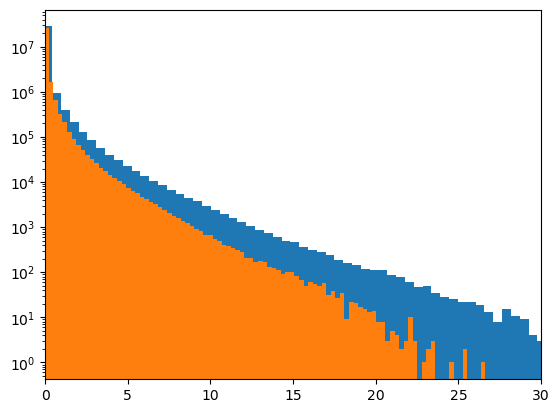

In [28]:
numpyrize = lambda x: x.cpu().detach().numpy()
Pr_true = numpyrize(Pr_batch).flatten()
Pr_pred = numpyrize(Pr_pred_batch).flatten()

plt.hist(Pr_true, bins=100)
plt.hist(Pr_pred, bins=100)
plt.yscale('log')
plt.xlim(0, 30)

In [13]:
numpyrize = lambda x: x.cpu().detach().numpy()
Pr_combined = np.array([numpyrize(Pr_pred_resnonlin).flatten(), numpyrize(Pr_resnonlin).flatten()])
np.save('20260327125800_Pr_combined_residual_nonlinear_ODE_latent_dims=4_complexity=5p10_tp=20_global_oceanland.npy', Pr_combined)

In [11]:
Pr_combined = np.array([numpyrize(Pr_pred_nonlin).flatten(), numpyrize(Pr_nonlin).flatten()])
np.save('20260327125800_Pr_combined_nonlinear_ODE_latent_dims=4_tp=20_global_oceanland.npy', Pr_combined)

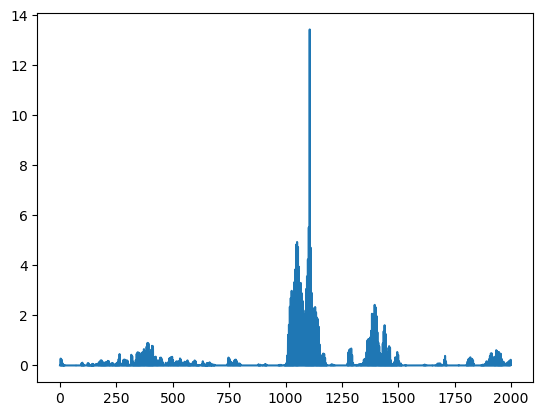

In [368]:
plt.plot(numpyrize(Pr_batch)[:, 0])
#plt.plot(numpyrize(Pr_pred_batch)[:, 0])
#plt.scatter(np.arange(Pr_batch.shape[0]), numpyrize(Pr_batch)[:, 0])

In [331]:
nn.MSELoss(reduction='sum')(Pr_pred_batch, Pr_batch) / Pr_batch.shape[0]

tensor(6.7188e+13, device='cuda:0', grad_fn=<DivBackward0>)

In [236]:
XP_train.shape

torch.Size([81920, 2137, 8])

In [278]:
t_rollout = 2000
tmax_train = XP_train.shape[1]
tmax_val = XP_val.shape[1]
t_prediction_train = np.arange(start=t_rollout, stop=tmax_train, step=t_rollout)
#coords = np.arange(64)
coords = np.array([1234])
XP_batch = XP_train[::sep][coords] # grab batch
Z_batch = Z_train[::sep][coords]
print(XP_batch.shape, Z_batch.shape)
Z_ED, Z_AE, xp, p = model_online.forward_Z(coords, XP_batch, Z_batch, t_prediction_train, t_rollout)
numpyrize = lambda x: x.cpu().detach().numpy()
Z_ED_np, Z_AE_np = numpyrize(Z_ED), numpyrize(Z_AE)
xp, p = numpyrize(xp), numpyrize(p)

torch.Size([1, 2137, 8]) torch.Size([1, 2137, 4])


In [257]:
Z_ED_np.shape

(2000, 1, 1, 4)

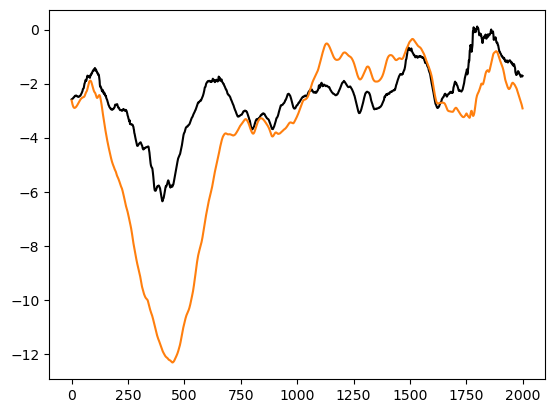

In [279]:
var = 2
for i in range(Z_ED_np.shape[2]):
    t = np.arange(i*t_rollout, (i+1)*t_rollout)
    plt.plot(t, Z_AE_np[:, 0, i, var], color='black')
    plt.plot(t, Z_ED_np[:, 0, i, var], color='tab:orange')

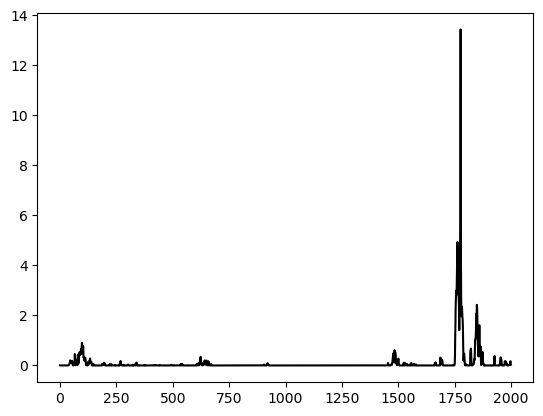

In [289]:
feature = 7
for i in range(Z_ED_np.shape[2]):
    t = np.arange(i*t_rollout, (i+1)*t_rollout)
    plt.plot(t, xp[:, 0, i, feature], color='black')

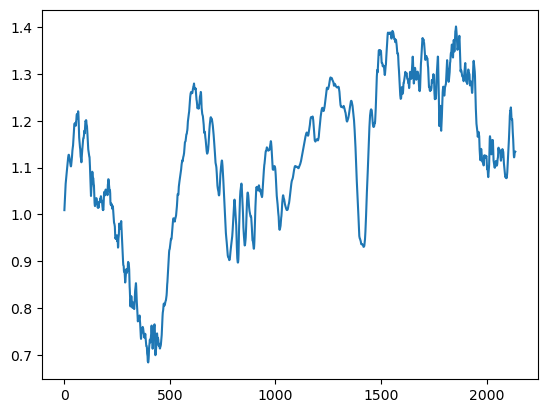

In [283]:
x = numpyrize(X)
plt.plot(x[0, :, feature])

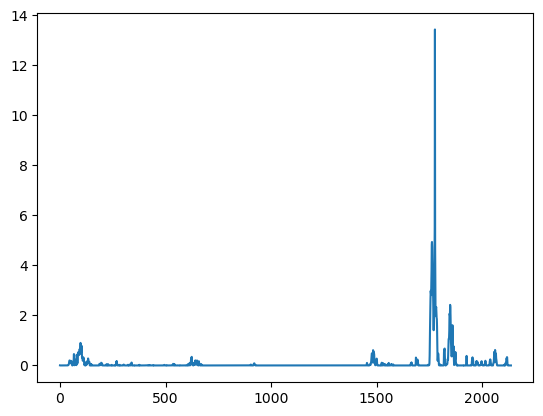

In [290]:
plt.plot(XZ_train[::sep][1234, :, 8])

In [32]:
with open('linear_ODE_4d_sympy_equations.pkl', 'rb') as file:
    model_st = pickle.load(file)

In [4]:
def load_NNODE_checkpoint(path):
    checkpoint = torch.load(path, map_location=device)
    model = NN_ODE(**checkpoint['model_kwargs'])
    model.ODE.load_state_dict(checkpoint['ODE_state'], )
    model.neural_net.load_state_dict(checkpoint['NN_state'])
    model.set_metadata(checkpoint['metadata'])

    return model

path = 'networks/NN_ODE/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260318180651.pkl'
model_cp = load_NNODE_checkpoint(path)

NameError: name 'NN_ODE' is not defined

In [38]:
train_ODE_online(model_cp, XZ_train, XZ_val, t_rollouts=[100], epochs=3)

Training: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3/3 [00:03<00:00,  1.20s/it, Train Loss=1.4540, Val Loss=0.0003, R2=1.0000]


NN_ODE(
  (ODE): SymPyModule(expressions=(0.0125845298171043*Fl - 0.2283227443695068*Fs + 0.0335674025118351*Prw - 0.0067300507798791*T2m + 0.0346834696829319*Ts - 0.0724688395857811*qv2m - 0.0297117158770561*z1 - 0.0242571663111448*z2 + 0.0130181424319744*z3 + 0.0161656737327576*z4 + 0.0129189640283585, -0.1224308237433434*Fl + 0.8090240955352783*Fs + 0.3766121864318848*Prw - 0.2043185532093048*T2m - 0.1669906079769135*Ts - 0.1181593537330627*qv2m + 0.0977997630834579*z1 - 0.051957942545414*z2 - 0.0944732129573822*z3 - 0.0436104275286198*z4 - 0.3531173169612885, 0.0073874341323972*Fl + 0.2853155434131622*Fs + 0.0649070665240288*Prw + 0.0749631822109222*T2m - 0.0313548110425472*Ts - 0.0176339223980904*qv2m + 0.0366671569645405*z1 + 0.0144942309707403*z2 - 0.0376300364732742*z3 - 0.0196049474179745*z4 - 0.1287428289651871, -0.1276683211326599*Fl + 0.3921521306037903*Fs - 0.1407610923051834*Prw + 0.2085391134023666*T2m + 0.0968972891569138*Ts - 0.0327436849474907*qv2m + 0.009595570154488

In [31]:
cp['model_kwargs']

{'path_ODE': 'linear_ODE_4d_sympy_equations.pkl',
 'dt': 1,
 'path_to_AE_model': 'networks/ConvNN+AE+D/n_features=7_memory_indices=[0, 1, 2, 3, 4, 5]_latent_dims=4_past_timesteps=20/20260128182053_global_ocean_land_rp=False_alpha=0.5_lr=0.001_weigth_decay=0.0_eps=1.0.pkl'}

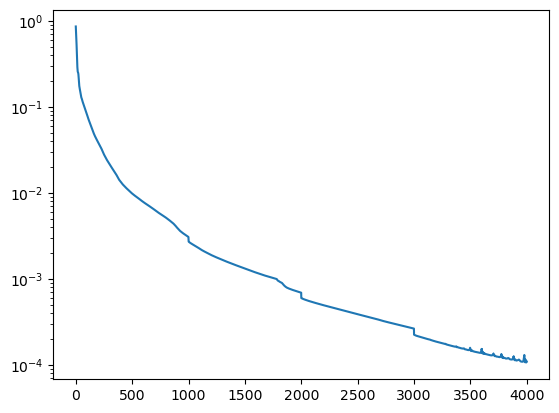

In [81]:
plt.plot(model_online.train_loss)
plt.yscale('log')

(0.0, 0.001)

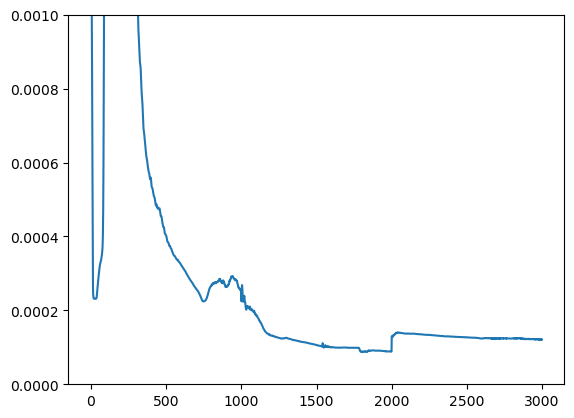

In [82]:
plt.plot(model_online.val_loss)
plt.ylim(0.0, .001)

In [96]:
model_online.save()

AttributeError: Can't get local object '_Node.__init__.<locals>.<lambda>'

In [97]:
for p in model_online.parameters():
    print(p)

Parameter containing:
tensor(-0.1218, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(-0.0418, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.0427, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.3632, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(-0.0527, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(-0.7406, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(-0.0074, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.3708, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(-0.4165, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(-1.0173, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.2894, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.0777, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.2393, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.

In [15]:
from torchmetrics.regression import R2Score

In [92]:
for p in models_st.parameters():
    print(p)

Parameter containing:
tensor(-0.1218, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(-0.0418, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.0427, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.3632, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(-0.0527, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(-0.7406, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(-0.0074, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.3708, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(-0.4165, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(-1.0173, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.2894, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.0777, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.2393, device='cuda:0', requires_grad=True)
Parameter containing:
tensor(0.

In [13]:
R2Score()(Pr_pred_batch, Pr_batch)

tensor(-167.7263, grad_fn=<CloneBackward0>)

In [215]:
print(Z_ED_batch.shape, XP_batch.shape)

torch.Size([4000, 4]) torch.Size([4000, 7])


In [216]:
Z_ED.shape

torch.Size([20, 200, 4])

In [217]:
Z_ED_normal_dims = Z_ED.reshape(t_rollout, len(coords), len(t_prediction), latent_dims)
Z_ED_normal_dims.shape

torch.Size([20, 4, 50, 4])

In [218]:
Z_ED_normal_dims.shape

torch.Size([20, 4, 50, 4])

In [219]:
Z_ED_numpy = Z_ED_single_t.detach().numpy()
Z_ED_nd_numpy = Z_ED_normal_dims.detach().numpy()
#Z_ED_multi_t_numpy = torch.concat((Z_ED_normal_dims[:, :, 0, :], Z_ED_normal_dims[:, :, 1, :]), dim=0)#.reshape(1000, 2, 4).detach().numpy()
Z_ED_multi_t_numpy = (
    Z_ED_normal_dims
    .permute(2, 0, 1, 3)   # move dim=3 next to dim=0 (actually before it)
    .reshape(-1, Z_ED_normal_dims.shape[2], Z_ED_normal_dims.shape[3])
).detach().numpy()

In [220]:
Z_ED_multi_t_numpy.shape

(80, 50, 4)

In [23]:
z_pysindy = model.simulate(x0=z_train[123][0], u=x_train[123][:tmax], t=np.arange(tmax))
z_pysindy

/work/bd1179/b309297/conda_envs/DYAMOND_env/lib/python3.13/site-packages/pysindy/pysindy.py:748: UserWarning: Last time point dropped in simulation because interpolation of control input was used. To avoid this, pass in a callable for u.
  warnings.warn(


array([[ 1.03406775, -4.05867863, -5.53044128,  4.4719305 ],
       [ 1.10100286, -4.22302341, -5.62456105,  4.47158288],
       [ 1.17127991, -4.36717729, -5.71959571,  4.46364502],
       ...,
       [ 1.90808053, -0.69403464, -4.25785153,  4.95557037],
       [ 1.9116226 , -0.71396512, -4.24975345,  5.00399223],
       [ 1.91656701, -0.73515296, -4.2429274 ,  5.04852027]],
      shape=(2136, 4))

Text(0, 0.5, 'Z')

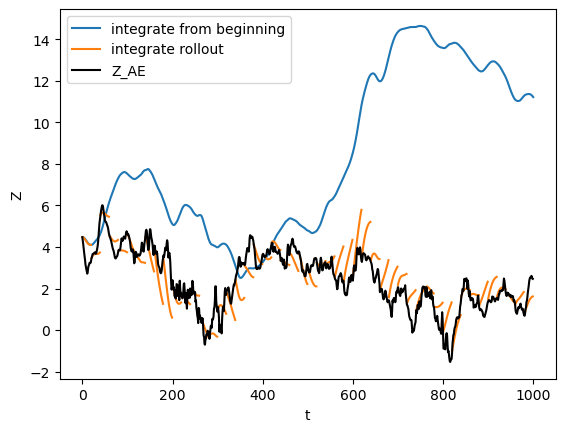

In [224]:
var = 3
#plt.plot(z_pysindy[:, var])
#plt.plot(Z_sim[:-1, 0, var])
plt.plot(np.arange(1000 -1000+1, 1000+1), Z_ED_numpy[:, 0, var], label='integrate from beginning')
#plt.plot(np.arange(0, 500), Z_ED_nd_numpy[:, 0, 0, var])
#plt.plot(np.arange(500, 1000), Z_ED_nd_numpy[:, 0, 1, var])
first = True
for i, tp in enumerate(t_prediction):
    label = None
    if first:
        label = 'integrate rollout'
        first = False
    plt.plot(np.arange(tp-t_rollout, tp), Z_ED_nd_numpy[:, 0, i, var], color='tab:orange', label=label)
#plt.plot(np.arange(1, 1001), Z_ED_multi_t_numpy[:, 0, var])
plt.plot(z_train[123][:1000, var], color='black', label='Z_AE')
plt.legend()
plt.xlabel('t')
plt.ylabel('Z')

In [117]:
Z_sim = np.array(Z_sim)
Z_sim.shape

(101, 2, 4)

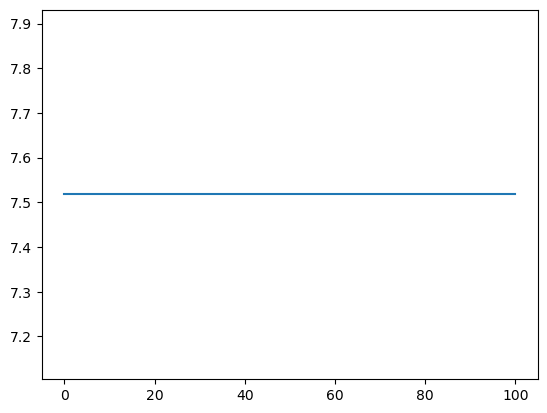

In [120]:
plt.plot(Z_sim[:, 0, 3])

### Train NN to predict the derivatives of Z

In [21]:
# Set important metadata for derivative learning with NN
latent_dims = 5
n_features = 6
coordinate_available = True

In [4]:
# Remove the coordinate dimension if available
if coordinate_available:
    coords_train = XZ_train[:, :, 0]
    XZ_train = XZ_train[:, :, 1:]
    coords_test = XZ_val[:, :, 0]
    XZ_val = XZ_val[:, :, 1:]
    coordinate_available = False

In [22]:
# Compute derivates
def get_derivative(XZ, first_Z_ind):
    dm = ps.FiniteDifference()
    # dm = ps.SmoothedFiniteDifference(smoother_kws={'window_length': 10})
    dZdt = np.array([dm._differentiate(Z[:, first_Z_ind:], t=1) for Z in XZ])
    dZdt = torch.tensor(dZdt, dtype=torch.float32)
    return dZdt

dZdt_train = get_derivative(XZ_train, first_Z_ind=-latent_dims)
dZdt_test = get_derivative(XZ_val, first_Z_ind=-latent_dims)

In [23]:
class CoordDataset(Dataset):
    def __init__(self, X):
        self.X = X
        self.num_coords, self.NT, self.N_features = X.shape

    def __len__(self):
        return self.num_coords

    def __getitem__(self, idx):
        return idx

def get_dataloaders(XZ_train, XZ_test, dZdt_test, n_features, batch_size=32, num_workes=10):
    # inds_except_precip = list(range(XZ_train.shape[-1]))
    # inds_except_precip.pop(n_features)
    # inds_except_precip.pop(n_features)
    inds_except_precip = [1, 2, 3, 4, 5, 6, -4, -3, -2, -1]
    print(inds_except_precip)
    train_dataset = CoordDataset(XZ_train[:, :, inds_except_precip])
    test_dataset = CoordDataset(XZ_test[:, :, inds_except_precip])

    trainloader = DataLoader(train_dataset, batch_size=batch_size, num_workers=num_workes)
    testloader = DataLoader(test_dataset, batch_size=batch_size, num_workers=num_workes)

    latent_dims = dZdt_test.shape[-1]
    dZdt_test_flatt = dZdt_test.view(-1, latent_dims)
    dZdt_mean = torch.mean(dZdt_test_flatt, axis=0)
    SStot_test = torch.sum((dZdt_test_flatt - dZdt_mean)**2, dim=0).to(device)
    return trainloader, testloader, SStot_test

trainloader, testloader, SStot = get_dataloaders(torch.tensor(XZ_train, dtype=torch.float32), torch.tensor(XZ_val, dtype=torch.float32), 
                                                 dZdt_test, n_features, num_workes=0, batch_size=64)

[1, 2, 3, 4, 5, 6, -4, -3, -2, -1]


In [24]:
class NN(nn.Module):
    def __init__(self, latent_dims, n_features, nodes_per_layer=16):
        nn.Module.__init__(self)
        
        self.latent_dims = latent_dims
        self.n_features = n_features
        self.n_features_in = self.latent_dims + self.n_features
        self.n_features_out = latent_dims
        self.nodes_per_layer = nodes_per_layer
        self.model_name = 'NNbase'
        self.X, self.Y = None, None
        self.X_test, self.Y_test = None, None

        self.neural_net = nn.Sequential(
            nn.Linear(self.n_features_in, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.nodes_per_layer),
            nn.ReLU(),
            nn.Linear(self.nodes_per_layer, self.n_features_out)
        )

        self.R2 = []
        self.train_loss = []
        self.test_loss = []
    
    def forward(self, x):
        return self.neural_net(x)

In [25]:
def preprocess(ind, x, y, latent_dims, n_features):
    x_batch, y_batch = x[ind], y[ind]
    #x_batch = torch.cat(tuple(x_batch), dim=0)
    x_batch = x_batch.reshape(-1, latent_dims + n_features)
    y_batch = y_batch.reshape(-1, latent_dims)
    #y_batch = torch.cat(tuple(y_batch), dim=0)
    return x_batch, y_batch

def simple_train(model, trainloader, testloader, SS_tot, num_epochs=10):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_func = nn.MSELoss()
    pbar = trange(num_epochs, desc="Training", ncols=150)

    for epoch in pbar:
        model.train()
        train_loss = 0
        for ind in trainloader:
            x_batch, y_batch = preprocess(ind, model.X, model.Y, model.latent_dims, model.n_features)
            y_pred = model.forward(x_batch)
            loss = loss_func(y_pred, y_batch)

            # Back propagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss = train_loss / len(trainloader)

        model.eval()
        test_loss = 0
        SS_res = 0
        with torch.no_grad():
            for ind in testloader:
                x_batch, y_batch = preprocess(ind, model.X_test, model.Y_test, model.latent_dims, model.n_features)
                y_pred = model.forward(x_batch)
                test_loss += loss_func(y_pred, y_batch).item()
                SS_res += torch.sum((y_batch - y_pred)**2, dim=0)
        test_loss = test_loss / len(testloader)
        # R2 = torch.mean(1 - SS_res / SS_tot).item()
        R2 = 1 - SS_res / SS_tot
        model.R2.append(R2.detach().cpu())
        model.train_loss.append(train_loss)
        model.test_loss.append(test_loss)
        # print(R2)

        pbar.set_postfix({
            "Train Loss": f"{train_loss:.8f}",
            "Test Loss": f"{test_loss:.8f}",
            "R2": f"{torch.mean(R2)}"
            })

In [9]:
XZ_train.shape

(81920, 2137, 13)

In [10]:
dZdt_train.shape

torch.Size([81920, 2137, 3])

In [5]:
n_features = 5
latent_dims= 3
list(range(1, n_features + 1)) + list(range(-latent_dims, 0))

[1, 2, 3, 4, 5, -3, -2, -1]

In [26]:
model = NN(latent_dims=latent_dims, n_features=n_features)
# inds_except_precip = list(range(XZ_train.shape[-1]))
# inds_except_precip.pop(n_features)
# inds_except_precip.pop(n_features)
inds_except_precip = [1, 2, 3, 4, 5, 6, -5, -4, -3, -2, -1]#[1, 2, 3, 4, 5, 6, 7, -5, -4, -3, -2, -1] # [1, 2, 3, -3, -2, -1]
# inds_except_precip.pop(n_features - 1)
print(inds_except_precip)
model.X = torch.tensor(XZ_train[:,:, inds_except_precip], dtype=torch.float32, device=device)
model.X_test = torch.tensor(XZ_val[:,:, inds_except_precip], dtype=torch.float32, device=device)
model.Y = dZdt_train.to(device)
model.Y_test = dZdt_test.to(device)
simple_train(model, trainloader, testloader, SStot, num_epochs=200)

[1, 2, 3, 4, 5, 6, -5, -4, -3, -2, -1]


Training: 100%|█████████████████████████████████| 200/200 [09:07<00:00,  2.74s/it, Train Loss=0.00985823, Test Loss=0.01138091, R2=0.7841085195541382]


In [27]:
mean_R2 = [torch.mean(R2) for R2 in model.R2]
max(mean_R2)

tensor(0.7843)

In [11]:
# Save model
save_path = 'networks/NN_ODE/ConvNN+AE+D/20251215092753_n_features=3trunc_latent_dims=3_past_timesteps=20_global_ocean_land_rp=False_tp=20_wd=0.0.pt'
torch.save(model.state_dict(), save_path)

### Can the NN still learn the derivatives with PySR data setup?

In [ ]:
# PySR data prep
latent_dims = 3
coord_skipper = 50
tmin = 1000
tmax = 1200
n_features = 3
input_indices = [1, 2, 3, -3, -2, -1]
# subset_size = 10_000

xz_train = XZ_train[::coord_skipper, tmin:tmax, input_indices]
xz_test = XZ_val[::coord_skipper, :, input_indices]
print(xz_train.shape)
dZdt_train = get_derivative(xz_train, first_Z_ind=-latent_dims)
dZdt_test = get_derivative(xz_test, first_Z_ind=-latent_dims)
feature_names = ['qv2m', 'Prw', 'T2m', 'z1', 'z2', 'z3']

# Reshape for SR
xz_train = torch.tensor(xz_train.reshape(-1, n_features + latent_dims), dtype=torch.float32, device=device)
dZdt_train = dZdt_train.reshape(-1, latent_dims).to(device)
xz_test = torch.tensor(xz_test.reshape(-1, n_features + latent_dims), dtype=torch.float32, device=device)
dZdt_test = dZdt_test.reshape(-1, latent_dims).to(device)

(4096, 1000, 6)


In [23]:
# Training in the PySR setup
num_epochs = 20000
model = NN(latent_dims=latent_dims, n_features=n_features)
model = model.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_func = nn.MSELoss()
pbar = trange(num_epochs, desc="Training", ncols=150)
R2_func = R2Score().to(device)
for epoch in pbar:
    model.train()
    y_pred = model.forward(xz_train)
    loss = loss_func(y_pred, dZdt_train)

    # Back propagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    train_loss = loss.item()

    model.eval()
    test_loss = 0
    with torch.no_grad():
        y_pred = model.forward(xz_test)
        test_loss = loss_func(y_pred, dZdt_test).item()
    R2 = R2_func(y_pred, dZdt_test)

    model.R2.append(R2.detach().cpu())
    model.train_loss.append(train_loss)
    model.test_loss.append(test_loss)

    pbar.set_postfix({
        "Train Loss": f"{train_loss:.8f}",
        "Test Loss": f"{test_loss:.8f}",
        "R2": f"{torch.mean(R2)}"
        })

Training:   0%|                                         | 0/20000 [00:00<?, ?it/s, Train Loss=0.12552747, Test Loss=0.12834589, R2=-1.172978162765503]

Training: 100%|█████████████████████████████| 20000/20000 [13:21<00:00, 24.96it/s, Train Loss=0.02293503, Test Loss=0.02502995, R2=0.7214145064353943]


In [11]:
dZdt_train.shape

torch.Size([327800, 3])

In [16]:
dZdt_train = get_derivative(XZ_train, first_Z_ind=-latent_dims)  # +2 for precip_pred and precip_true, +1 for coord
dZdt_test = get_derivative(XZ_val, first_Z_ind=-latent_dims)  

In [52]:
dZdt_train.shape
test = np.array(XZ_train[:,:, [1, 2, 3, -3, -2, -1]])
test.shape

(81920, 2137, 6)

In [54]:
(81920, 2137, 6)
test_con = []
for i in range(81920):
    for j in range(2137):
        test_con.append(test[i, j, :])
test_con = np.array(test_con)
test_con.shape

(175063040, 6)

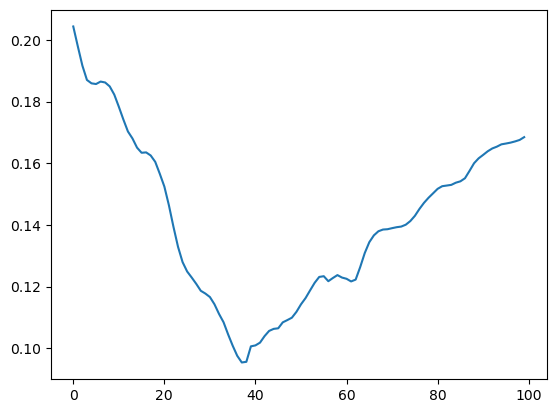

In [57]:
plt.plot(test_con[10000:10100,2])

In [58]:
test_con.mean(axis=0)

array([-0.00968997, -0.00984898, -0.00800006, -7.111075  , -0.27997833,
       -3.343552  ], dtype=float32)

In [62]:
-0.010733 * 0.18851 -  0.0002

-0.0022232778300000002

In [60]:
dZdt_train.reshape(-1, 3).mean(axis=0)

tensor([ 0.0002,  0.0002, -0.0002])

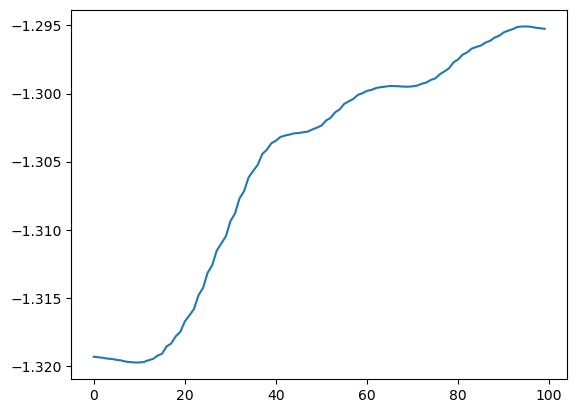

In [49]:
plt.plot(XZ_train[1234, 1000:1100, 2])

In [42]:
XZ_train.shape

(81920, 2137, 13)

In [26]:
XZ_train.shape

(81920, 2137, 13)

In [ ]:
def make_dzdt(model, testloader, X, Y, inds_except_precip_coord, save_path):
    model.eval()
    XYdzdt = []
    Ys = []
    with torch.no_grad():
        for ind in testloader:
            # print(model.X_test.shape)
            coord_precip = X[ind, :, :]  
            coord_precip = coord_precip[:, :, [0, 8, 9]]  # coordinate and precip indices
            coord_precip = coord_precip.reshape(-1, 3)
            x_batch, y_batch = preprocess(ind, X[:,:, inds_except_precip_coord], Y, 
                                          model.latent_dims, model.n_features)
            Ys.append(y_batch.detach().cpu().numpy())
            #print(x_batch.shape, y_batch.shape)
            y_pred = model.forward(x_batch)
            XYdzdt.append(torch.cat((coord_precip, x_batch, y_pred), dim=1).detach().cpu().numpy())
    # Ys = np.concat(Ys, axis=0)
    # XYdzdt = np.concat(XYdzdt, axis=0)
    Ys = np.array(Ys)
    XYdzdt = np.array(XYdzdt)
    print(R2Score()(torch.tensor(XYdzdt[:, :, -model.latent_dims:]).reshape(-1, model.latent_dims), torch.tensor(Ys).reshape(-1, model.latent_dims)))
    print(Ys.shape)
    print(XYdzdt.shape)
    return XYdzdt

# inds_except_precip_coord = list(range(XZ_train.shape[-1]))
# inds_except_precip_coord.pop(0)
# inds_except_precip_coord.pop(n_features)
# inds_except_precip_coord.pop(n_features)
inds_except_precip_coord = [1, 2, 3, -3, -2, -1]
# inds_except_precip.pop(n_features - 1)
print(inds_except_precip_coord)
model1 = NN(latent_dims=latent_dims, n_features=n_features)
model1 = model1.to(device)
model1.X = torch.tensor(XZ_train, dtype=torch.float32, device=device)
model1.X_test = torch.tensor(XZ_val, dtype=torch.float32, device=device)
print(model1.X_test.shape, len(inds_except_precip_coord))
model1.Y = dZdt_train.to(device)
model1.Y_test = dZdt_test.to(device)
# print(model1.X_test.device, model1.Y_test.device)
model1.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
# model1.eval()
trainloader, testloader, SStot = get_dataloaders(torch.tensor(XZ_train, dtype=torch.float32), torch.tensor(XZ_val, dtype=torch.float32), 
                                                 dZdt_test, n_features, num_workes=10, batch_size=1)
XYdZdt = make_dzdt(model1, trainloader, model1.X, model1.Y, inds_except_precip_coord, None)

In [15]:
XYdZdt.shape

(81920, 2137, 16)

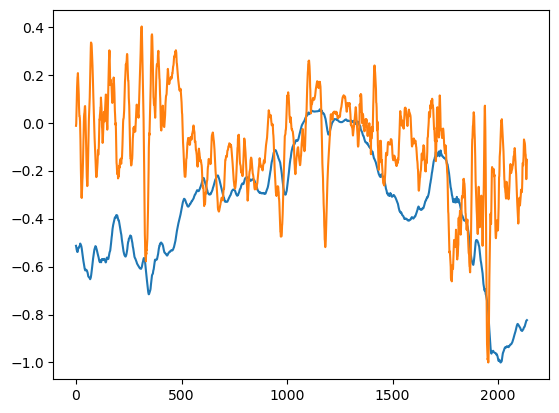

In [17]:
coord = 1078
plt.plot(XYdZdt[coord, :, 11] / np.max(abs(XYdZdt[coord, :, 11])))
plt.plot(XYdZdt[coord, :, 14] / np.max(abs(XYdZdt[coord, :, 14])))

In [14]:
path = 'dZdt_data/ConvNN+AE+D/20251215092753_train_n_features=7_latent_dims=3_past_timesteps=20_global_ocean_land_rp=False_tp=20_wd=0.0.npy'
np.save(path, XYdZdt)

In [ ]:
# Make and save dzdt predictions
model = torch.load(save_path, map_location=device)
inds_except_precip_coord = list(range(XZ_train.shape[-1]))
inds_except_precip_coord.pop(0)
inds_except_precip_coord.pop(n_features)
inds_except_precip_coord.pop(n_features)
# inds_except_precip.pop(n_features - 1)
print(inds_except_precip_coord)
model.X = torch.tensor(XZ_train[:,:, inds_except_precip_coord], dtype=torch.float32, device=device)
model.X_test = torch.tensor(XZ_val[:,:, inds_except_precip_coord], dtype=torch.float32, device=device)
model.Y = dZdt_train.to(device)
model.Y_test = dZdt_test.to(device)
simple_train(model, trainloader, testloader, SStot, num_epochs=200)

[1, 2, 3, 4, 5, 6, 7, 10, 11, 12]


In [26]:
XZ_train.shape

(81920, 2137, 13)

(0.0, 30.0)

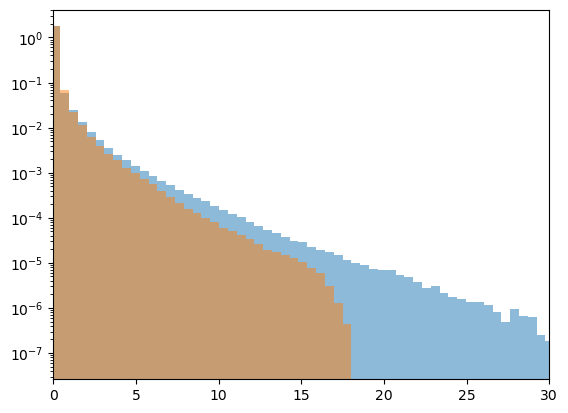

In [11]:
_, bins, _ = plt.hist(XZ_val[:, :, 7].flatten()[::], density=True, bins=100, alpha=0.5)
plt.hist(XZ_val[:, :, 8].flatten()[::], density=True, bins=bins, alpha=0.5)
plt.yscale('log')
#plt.ylim(10, 3.e7)
plt.xlim(0, 30)

(0.0, 30.0)

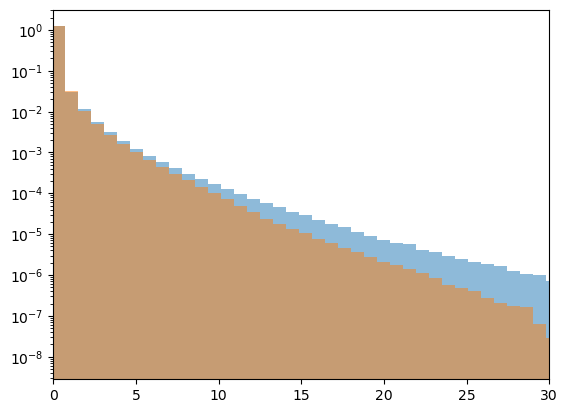

In [22]:
_, bins, _ = plt.hist(XZ_train[:, :, 7].flatten()[::], density=True, bins=100, alpha=0.5)
plt.hist(XZ_train[:, :, 8].flatten()[::], density=True, bins=bins, alpha=0.5)
plt.yscale('log')
#plt.ylim(10, 3.e7)
plt.xlim(0, 30)

In [11]:
XZ_train.shape

(81920, 2137, 12)

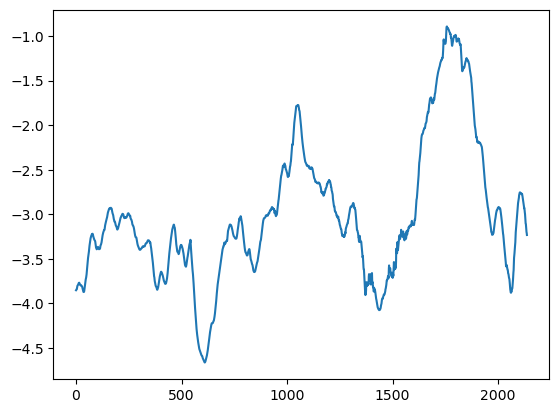

In [16]:
coord = 12318
plt.plot(XZ_train[coord, : , 10])

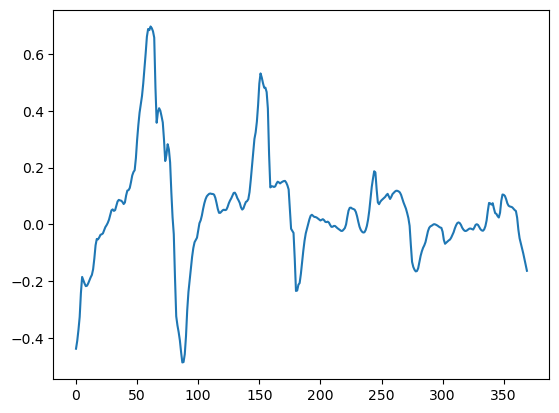

In [17]:
plt.plot(dZdt_test[coord, : , 2])

In [13]:
simple_train(model, trainloader, testloader, SStot, num_epochs=200)

Training: 100%|█████████████████████████████████| 200/200 [06:10<00:00,  1.85s/it, Train Loss=0.00025184, Test Loss=0.00030536, R2=0.5203140377998352]


0.520314


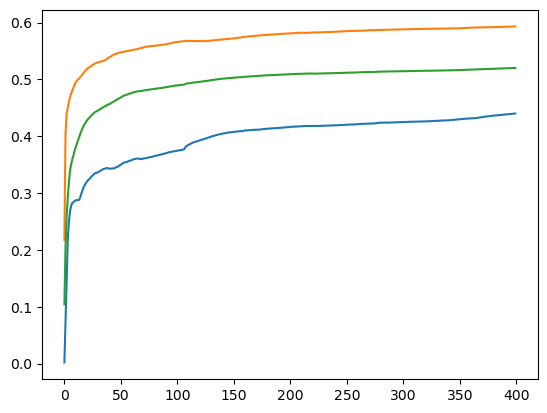

In [14]:
R2 = np.array([r2.detach().cpu().numpy() for r2 in model.R2])
plt.plot(np.min(R2, axis=1))
plt.plot(np.max(R2, axis=1))
plt.plot(np.mean(R2, axis=1))
print(np.max(np.mean(R2, axis=1)))

Text(0, 0.5, 'R^2')

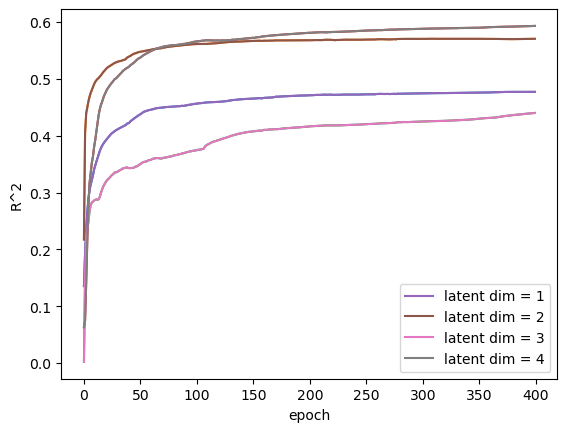

In [16]:
plt.plot(R2)
for i, r2 in enumerate(R2.T):
    plt.plot(r2, label=f'latent dim = {i + 1}')
plt.legend()
plt.xlabel('epoch')
plt.ylabel('R^2')

In [30]:
R2[np.argmax(np.sum(R2, axis=1))]

array([0.6242287, 0.4605518, 0.6899991, 0.7365465], dtype=float32)

### Remove land data and train ODE again

In [ ]:
ds = load_DYAMOND_data()

In [30]:
from training_gpu import get_standardized_ds
from parametrizations import load_grid

In [31]:
# Make 
region, surface = 'global', 'ocean_land'

ds = load_DYAMOND_data()
grid = load_grid()
# Mask specific region/surface
region_coords_dict = {'tropical': (-23, 23), 'global': (-180, 180)}
surface_mask_values_dict = {'ocean': -2, 'ocean_land': None}
region_mask = (grid.clat <= region_coords_dict[region][1]) & (grid.clat >= region_coords_dict[region][0])
if surface_mask_values_dict[surface]:
    surface_mask = grid.cell_sea_land_mask == surface_mask_values_dict[surface]
else: 
    surface_mask = np.ones_like(grid.cell_sea_land_mask, dtype=bool)
mask = surface_mask & region_mask

lon, lat = grid.clon.values, grid.clat.values
lon, lat = lon[mask], lat[mask]

In [32]:
land_mask = ds.is_land.isel({'time': 0}).values[mask]

In [ ]:
# lon, lat = ds_.clon.values, ds_.clat.values
# land_mask = ds_.is_land.isel({'time': 0}).values

In [59]:
coords = XZ_train[:, 0, 0].astype(int)

In [36]:
# coords_ocean = np.where((land_mask == 0) & (lat <=20) & (lat >= -20))[0]
#coords_ocean = np.where(land_mask == 0)[0]
#coords_ocean = np.where((land_mask == 0) | (land_mask == 1))[0]
coords_ocean = np.where(land_mask == 1)[0]
# coords_ocean = np.where((ds.is_land.isel({'time': 0}) & (lat <=20) & (lat >= -20)) == 0)[0]
sep = None
coords_ocean = coords_ocean[::sep]

In [37]:
coords_ocean

array([    0,     1,     2, ..., 80890, 80891, 81087], shape=(24813,))

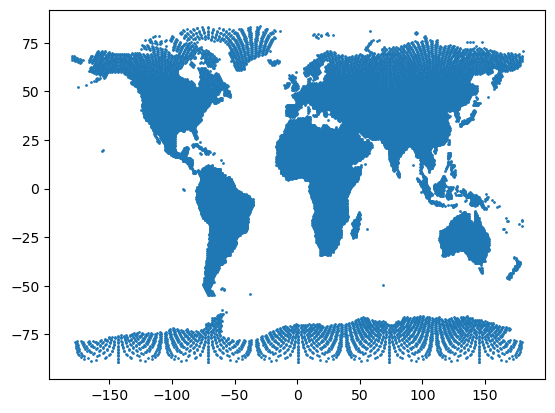

In [38]:
lon_o, lat_o = lon[coords_ocean], lat[coords_ocean]
plt.scatter(lon_o, lat_o, s=1)

In [39]:
coords_XZ = XZ_train[:, 0, 0].astype(int)

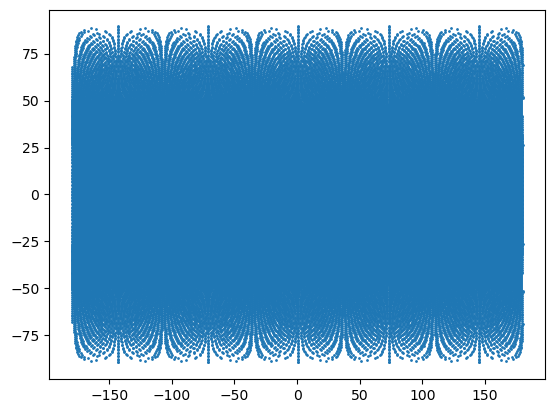

In [40]:
plt.scatter(lon[coords_XZ], lat[coords_XZ], s=1)

In [41]:
# map coords ocean to coords in xz training data
coords_XZ = XZ_train[:, 0, 0].astype(int)
coords_ocean_XZ = np.array([np.where(coords_XZ == co)[0][0] for co in coords_ocean])

In [42]:
XZ_train_ocean = XZ_train[coords_XZ[coords_ocean_XZ]]
XZ_val_ocean = XZ_val[coords_XZ[coords_ocean_XZ]]
lon_o, lat_o = lon[coords_XZ[coords_ocean_XZ]], lat[coords_XZ[coords_ocean_XZ]]

In [43]:
coords_XZ.shape

(81920,)

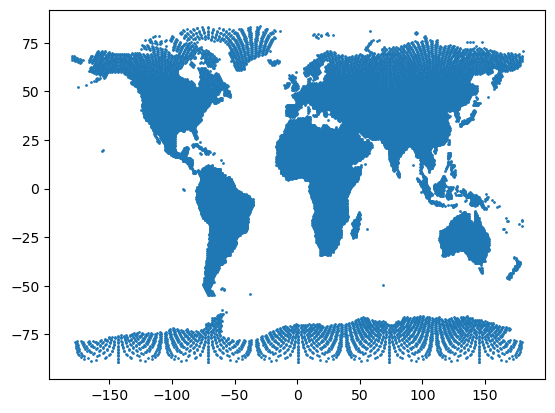

In [46]:
plt.scatter(lon[coords_XZ[coords_ocean_XZ]], lat[coords_XZ[coords_ocean_XZ]], s=1)

In [47]:
sep = 5
x_train_ocean = list(np.array(x_train)[coords_XZ[coords_ocean_XZ]][::sep])
z_train_ocean = list(np.array(z_train)[coords_XZ[coords_ocean_XZ]][::sep])
x_val_ocean = list(np.array(x_val)[coords_XZ[coords_ocean_XZ]][::sep])
z_val_ocean = list(np.array(z_val)[coords_XZ[coords_ocean_XZ]][::sep])

In [48]:
# Learn ODE without other Z_k variables
opt = ps.STLSQ(threshold=0.0)
lib = ps.PolynomialLibrary(degree=1)
model = ps.SINDy(feature_library=lib, 
                 differentiation_method=ps.FiniteDifference(), #ps.SmoothedFiniteDifference(smoother_kws={'window_length': 100}), 
                 optimizer=opt)

model.fit(x=z_train_ocean, u=x_train_ocean, t=1)
model.print()  
model.score(x=z_val_ocean, u=x_val_ocean, t=1)

(x0)' = -0.018 1 + -0.024 x0 + 0.006 x1 + -0.008 x3 + 0.005 x4 + 0.021 x5 + 0.017 x6 + -0.008 x7 + 0.005 x8 + 0.011 u0 + 0.002 u1 + 0.027 u2 + -0.024 u3 + 0.050 u4 + 0.001 u5 + -0.003 u6
(x1)' = 0.024 1 + 0.001 x0 + -0.010 x1 + 0.001 x2 + -0.013 x3 + -0.002 x4 + -0.006 x5 + 0.005 x6 + 0.004 x7 + 0.003 x8 + -0.007 u0 + 0.014 u1 + -0.026 u2 + -0.025 u3 + -0.012 u4 + 0.001 u5 + -0.009 u6
(x2)' = 0.016 1 + 0.024 x0 + -0.003 x2 + -0.005 x3 + -0.001 x4 + -0.006 x5 + -0.015 x6 + 0.008 x7 + 0.007 x8 + -0.014 u1 + -0.006 u2 + 0.024 u3 + -0.037 u4 + 0.003 u5 + 0.001 u6
(x3)' = 0.014 1 + 0.022 x0 + 0.001 x1 + -0.002 x2 + -0.005 x3 + -0.002 x4 + -0.002 x5 + -0.014 x6 + 0.006 x7 + 0.012 x8 + -0.008 u0 + -0.011 u1 + 0.016 u2 + 0.009 u3 + -0.023 u4 + -0.002 u5
(x4)' = 0.009 1 + -0.002 x0 + -0.011 x1 + 0.002 x2 + 0.015 x3 + -0.009 x4 + -0.011 x5 + -0.005 x6 + -0.002 x7 + -0.006 x8 + -0.021 u0 + 0.010 u1 + -0.055 u2 + 0.038 u3 + -0.002 u4 + 0.007 u6
(x5)' = -0.028 1 + -0.034 x0 + 0.004 x1 + 0.015 x2 + 

0.6140215498337006

### Z dot predictability map

In [12]:
R2_coord = np.zeros(shape=(model.X_test.shape[0], latent_dims))
loss = nn.MSELoss(reduction='none')
for i, (x_batch, y_batch) in enumerate(zip(model.X_test, model.Y_test)):
    #print(i)
    y_pred = model.forward(x_batch)
    #R2_coord[i] = R2Score(multioutput='raw_values')(y_pred, y_batch).detach().cpu().numpy()
    R2_coord[i] = torch.mean(loss(y_batch, y_pred), dim=0).detach().cpu().numpy()


In [15]:
coords_test = coords_test[:, 0].astype(int)

In [20]:
grid = load_grid()
lon, lat = grid.clon.values, grid.clat.values

In [21]:
lon

array([73.        , 73.91155751, 72.08844249, ..., 75.26973679,
       75.96269363, 76.78141492], shape=(81920,))

Text(0.5, 1.0, 'dZ/dt predictability')

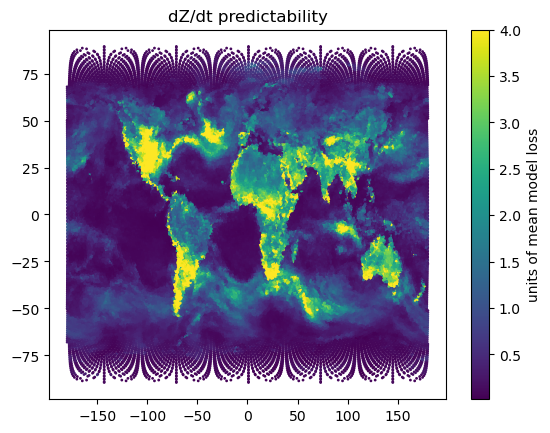

: 

In [ ]:
img = plt.scatter(lon[coords_test], lat[coords_test], c=np.mean(R2_coord, axis=1) / 0.00028111, s=1, cmap='viridis', vmax=4)
cbar = plt.colorbar(img)
cbar.set_label('units of mean model loss')
plt.title('dZ/dt predictability')

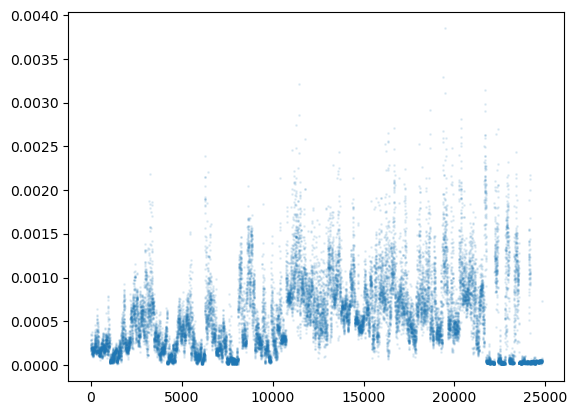

In [129]:
plt.scatter(range(24813), np.mean(R2_coord, axis=1), s=1, alpha=.1)
#plt.ylim(0, 1)

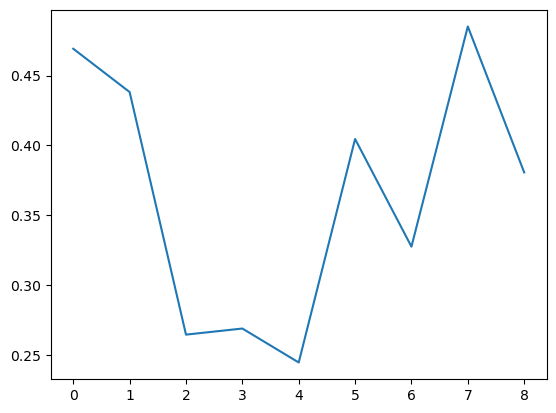

In [89]:
plt.plot(np.mean(R2_coord, axis=0))

In [90]:
R2_coord

array([[0.16238344, 0.49319422, 0.13996977, ..., 0.15284622, 0.51458001,
        0.17378998],
       [0.25022906, 0.52241933, 0.35944051, ..., 0.17760342, 0.45393354,
        0.36763269],
       [0.83251095, 0.56771719, 0.63296217, ..., 0.32559001, 0.72215497,
        0.54224074],
       ...,
       [0.94225198, 0.63772696, 0.68856472, ..., 0.47164476, 0.47259736,
        0.57909191],
       [0.43413812, 0.49131256, 0.44830477, ..., 0.39784545, 0.55549532,
        0.23843879],
       [0.32107836, 0.36999375, 0.4061076 , ..., 0.26373267, 0.42457026,
        0.33395827]], shape=(24813, 9))

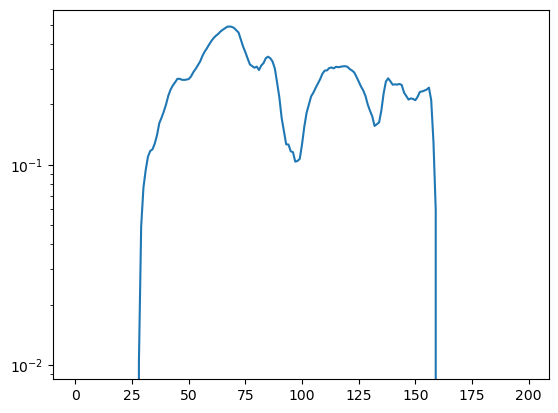

In [19]:
plt.plot(model.R2)
plt.yscale('log')

In [ ]:
_, testloader, SStot = get_dataloaders(torch.tensor(XZ_train, dtype=torch.float32), torch.tensor(XZ_val, dtype=torch.float32), 
                                                 dZdt_test, n_features, num_workes=0, batch_size=1)

### Investigate Z and dZdt

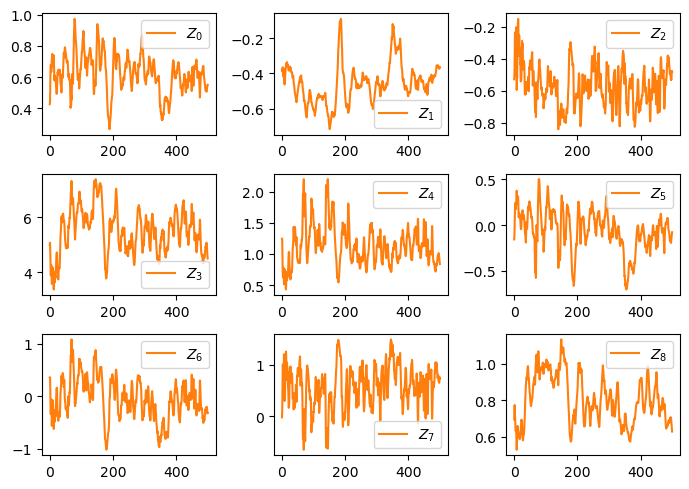

In [35]:
XZ_train
fig, axs = plt.subplots(3, 3, figsize=(7, 5))
axs = axs.flatten()
coord = 12351
tmax = 2000
time = np.arange(tmax) / 4

for i in range(7, 16):
    axs[i - 7].plot(time, XZ_train[coord, :tmax, i], label=rf'$Z_{{{i - 7}}}$', color='tab:orange')
    axs[i - 7].legend()

plt.tight_layout()

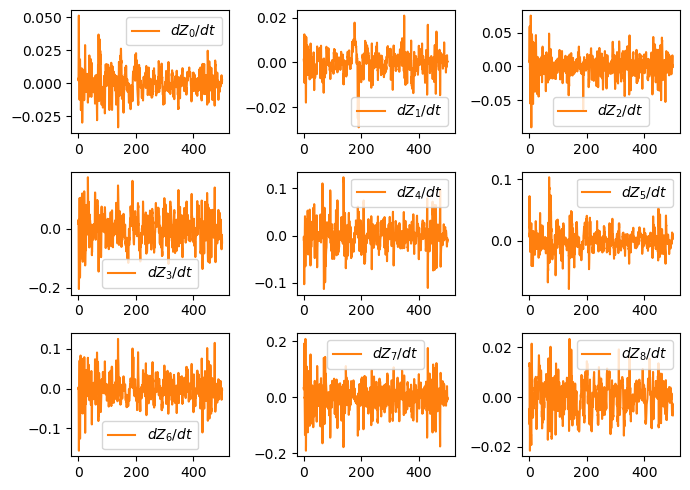

In [36]:
# Compute derivates 
dm = ps.FiniteDifference()
dzdt = dm._differentiate(z_train[coord], t=1)
fig, axs = plt.subplots(3, 3, figsize=(7, 5))
axs = axs.flatten()
for i in range(0, 9):
    axs[i].plot(time, dzdt[:tmax, i], label=rf'$dZ_{{{i}}}/dt$', color='tab:orange')
    axs[i].legend()

plt.tight_layout()

### Simulate ODE in time

In [37]:
tmax = 1000
t=np.arange(tmax) / 4
z_train_sim = model.simulate(z_train[coord][0], t=t, u=x_train[coord][:tmax])

/work/bd1179/b309297/conda_envs/DYAMOND_env/lib/python3.13/site-packages/pysindy/pysindy.py:748: UserWarning: Last time point dropped in simulation because interpolation of control input was used. To avoid this, pass in a callable for u.
  warnings.warn(


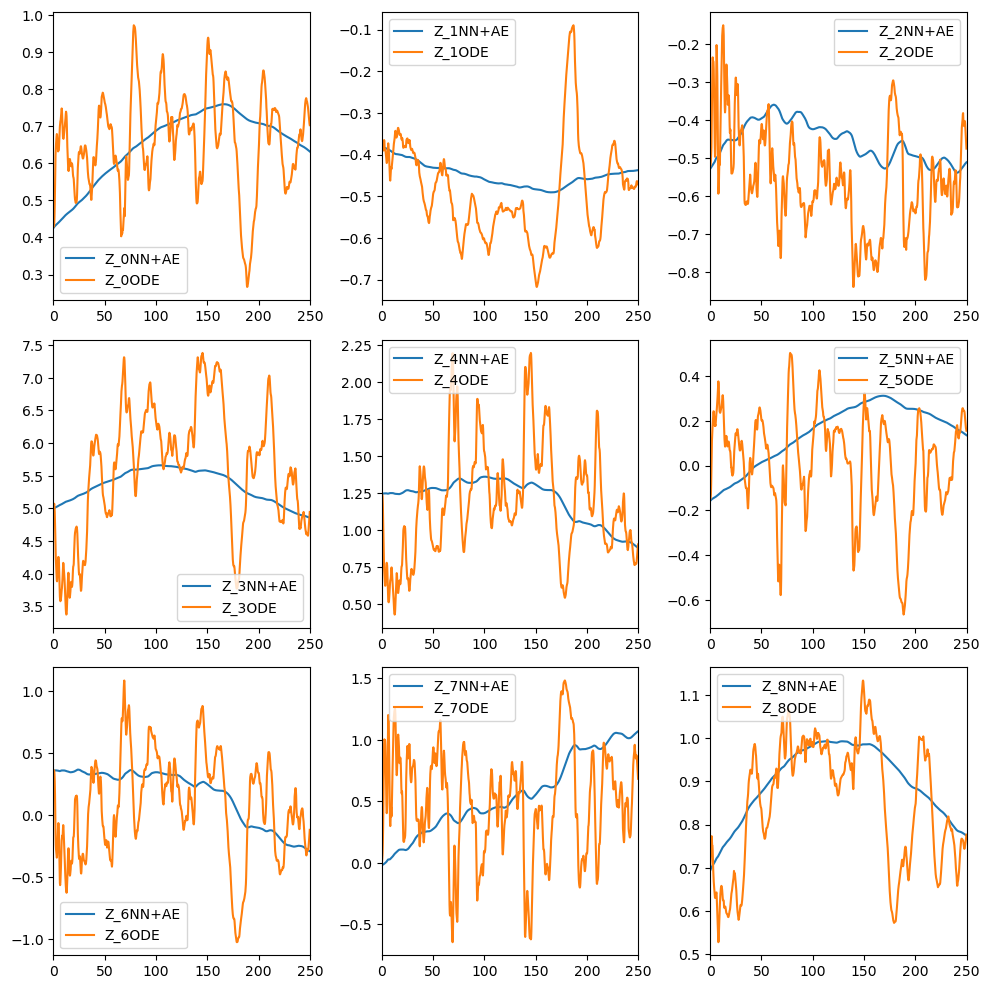

In [38]:
fig, axs = plt.subplots(3, 3, figsize=(10, 10))
axs = axs.flatten()
for i in range(0, 9):
    axs[i].plot(t[1:], z_train_sim[:, i], label=f'Z_{i}NN+AE')
    axs[i].plot(t[1:], z_train[coord][1:tmax, i], label=f'Z_{i}ODE')
    axs[i].legend()
    axs[i].set(xlim=(0, 250))

plt.tight_layout()